# 🔬 Gasification — EDA Complet v2
**Objectif :** Prédire la production d'hydrogène (H2_vol%) à partir des conditions de gazéification.

**Améliorations vs v1 :**
- ✅ Nettoyage complet (espaces, valeur négative, zéros)
- ✅ Identification des groupes d'expériences (Experiment_ID)
- ✅ Analyse temporelle par run
- ✅ Pairplot & outliers de toutes les features
- ✅ Feature engineering (nouvelles variables)
- ✅ Post-hoc Tukey pour Catalyst_Type
- ✅ Feature importance RF (non-linéaire)
- ✅ Bug section Top15 corrigé
- ✅ Insights preprocessing clairs pour la modélisation

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.facecolor": "white"})

TARGET    = "H2_vol"
C_H2      = "#1e88e5"
C_WARN    = "#e53935"
C_OK      = "#1D9E75"
PALETTE   = ["#1565c0","#00897b","#e65100","#6a1b9a","#c62828","#ad1457"]
print("✅ Bibliothèques importées  |  Cible :", TARGET)

✅ Bibliothèques importées  |  Cible : H2_vol


## 2. Chargement du dataset

In [2]:
DATA_PATH = "Gasification Dataset.csv"
data = pd.read_csv(DATA_PATH, sep=";")
print(f"Dataset brut : {data.shape[0]} lignes × {data.shape[1]} colonnes")
data.head(5)

Dataset brut : 3748 lignes × 9 colonnes


,Time,Temperature,ProcessTemperature,AgentType,AgentFlow,SampleType,CatalystType,CatalystRatio,Hydrogen
0,1,10,700,Air,0.05,TWTS,No Catalyst,0.0,0.0
1,2,11,700,Air,0.05,TWTS,No Catalyst,0.0,0.0
2,3,12,700,Air,0.05,TWTS,No Catalyst,0.0,0.0
3,4,16,700,Air,0.05,TWTS,No Catalyst,0.0,0.0
4,5,25,700,Air,0.05,TWTS,No Catalyst,0.0,0.0


## 3. Nettoyage & Renommage
**Corrections apportées (vs v1) :**
- Strip espaces trailing dans toutes les colonnes string
- Suppression de la valeur physiquement impossible H2 < 0
- Analyse et documentation des zéros dans la cible

In [3]:
# ── Renommage ──────────────────────────────────────────────────────────────
rename_map = {
    "Time"              : "Time_min",
    "Temperature"       : "Feed_Temp_C",
    "ProcessTemperature": "Reactor_Temp_C",
    "AgentType"         : "Agent_Type",
    "AgentFlow"         : "Agent_Flow_Lmin",
    "SampleType"        : "Sample_Type",
    "CatalystType"      : "Catalyst_Type",
    "CatalystRatio"     : "Catalyst_Ratio_pct",
    "Hydrogen"          : "H2_vol",
}
rename_map = {k: v for k, v in rename_map.items() if k in data.columns}
data.rename(columns=rename_map, inplace=True)

# ── Strip espaces trailing (CORRIGÉ v1) ─────────────────────────────────────
str_cols = data.select_dtypes(include="object").columns.tolist()
for c in str_cols:
    data[c] = data[c].str.strip()

data["Catalyst_Type"] = data["Catalyst_Type"].replace("None", "No Catalyst")

# ── Valeur négative H2 (CORRIGÉ v1) ─────────────────────────────────────────
n_neg = (data["H2_vol"] < 0).sum()
print(f"⚠️  Valeurs H2 < 0 trouvées : {n_neg}  → remplacées par 0")
data.loc[data["H2_vol"] < 0, "H2_vol"] = 0.0

# ── Analyse des zéros (NOUVEAU v2) ──────────────────────────────────────────
n_zeros   = (data["H2_vol"] == 0).sum()
pct_zeros = n_zeros / len(data) * 100
print(f"\n📊 Zéros dans H2_vol : {n_zeros} / {len(data)}  ({pct_zeros:.1f}%)")
print("   → Ces zéros correspondent à la phase de montée en température.")
print("   → Ils seront conservés pour la modélisation mais documentés.")

# ── Résumé colonnes ─────────────────────────────────────────────────────────
num_features = [c for c in data.columns if data[c].dtype != "O"]
cat_features  = [c for c in data.columns if data[c].dtype == "O"]
input_num     = [c for c in num_features if c != TARGET]
input_cat     = cat_features.copy()

print(f"\n✅ Colonnes : {list(data.columns)}")
print(f"   Valeurs manquantes : {data.isnull().sum().sum()}")
print(f"   Doublons           : {data.duplicated().sum()}")
print(f"   Catégories après strip :")
for c in input_cat:
    print(f"     {c}: {sorted(data[c].unique())}")

⚠️  Valeurs H2 < 0 trouvées : 1  → remplacées par 0

📊 Zéros dans H2_vol : 715 / 3748  (19.1%)
   → Ces zéros correspondent à la phase de montée en température.
   → Ils seront conservés pour la modélisation mais documentés.

✅ Colonnes : ['Time_min', 'Feed_Temp_C', 'Reactor_Temp_C', 'Agent_Type', 'Agent_Flow_Lmin', 'Sample_Type', 'Catalyst_Type', 'Catalyst_Ratio_pct', 'H2_vol']
   Valeurs manquantes : 0
   Doublons           : 0
   Catégories après strip :
     Agent_Type: ['Air', 'Oxygen']
     Sample_Type: ['Leather scraps', 'TWTS']
     Catalyst_Type: ['Al-Ni', 'Marble dust', 'No Catalyst']


## 4. Identification des groupes d'expériences (NOUVEAU v2)
**Pourquoi c'est critique :** `Time_min` représente le déroulement de plusieurs runs indépendants.
Chaque run = combinaison unique de conditions opératoires. Sans séparer les runs, les analyses temporelles sont incorrectes.


✅ Nombre d'expériences identifiées : 59
   Durée moyenne par run : 63.5 pas de temps
   Durée min : 36 | max : 101


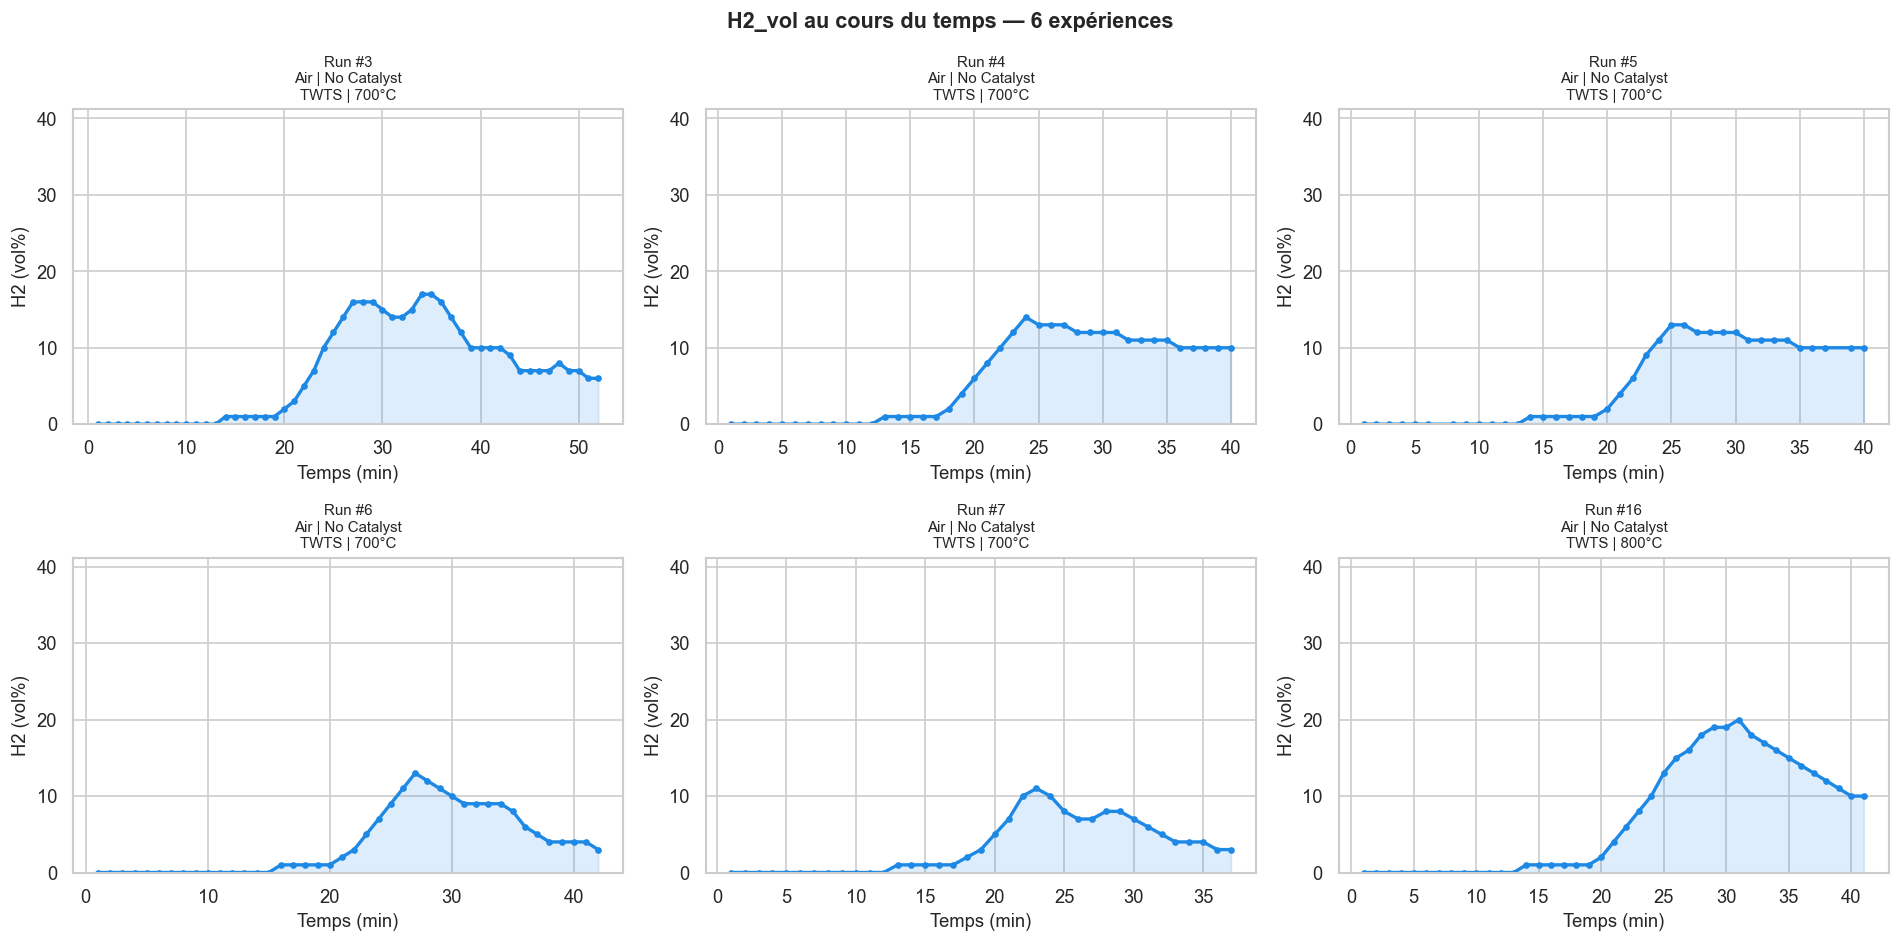

In [4]:
# ── Créer Experiment_ID ─────────────────────────────────────────────────────
group_cols = ["Reactor_Temp_C", "Agent_Type", "Agent_Flow_Lmin",
              "Sample_Type", "Catalyst_Type", "Catalyst_Ratio_pct"]

data["Experiment_ID"] = data.groupby(group_cols).ngroup() + 1

n_exp = data["Experiment_ID"].nunique()
print(f"✅ Nombre d'expériences identifiées : {n_exp}")
print(f"   Durée moyenne par run : {data.groupby('Experiment_ID')['Time_min'].count().mean():.1f} pas de temps")
print(f"   Durée min : {data.groupby('Experiment_ID')['Time_min'].count().min()} | max : {data.groupby('Experiment_ID')['Time_min'].count().max()}")

# ── Visualiser quelques runs ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
sample_ids = data["Experiment_ID"].unique()[:6]

for ax, eid in zip(axes.flat, sample_ids):
    run = data[data["Experiment_ID"] == eid].sort_values("Time_min")
    row = run.iloc[0]
    ax.plot(run["Time_min"], run["H2_vol"], color=C_H2, lw=2, marker="o", markersize=3)
    ax.fill_between(run["Time_min"], 0, run["H2_vol"], alpha=0.15, color=C_H2)
    ax.set_title(f"Run #{eid}\n{row['Agent_Type']} | {row['Catalyst_Type']}\n"
                 f"{row['Sample_Type']} | {row['Reactor_Temp_C']}°C", fontsize=9)
    ax.set_xlabel("Temps (min)"); ax.set_ylabel("H2 (vol%)")
    ax.set_ylim(0, data["H2_vol"].max() * 1.1)

plt.suptitle("H2_vol au cours du temps — 6 expériences", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

## 5. Vue générale du dataset

In [5]:
print("=== STATISTIQUES DESCRIPTIVES ===")
display(data[num_features].describe().round(3))

print("\n=== DISTRIBUTIONS CATÉGORIELLES ===")
for col in input_cat:
    if col != "Experiment_ID":
        vc = data[col].value_counts()
        print(f"\n{col} :")
        for val, cnt in vc.items():
            print(f"  {val:20s} → {cnt:5d} ({cnt/len(data)*100:.1f}%)")

=== STATISTIQUES DESCRIPTIVES ===


,Time_min,Feed_Temp_C,Reactor_Temp_C,Agent_Flow_Lmin,Catalyst_Ratio_pct,H2_vol
count,3748.000,3748.000,3748.000,3748.000,3748.000,3748.000
mean,34.646,677.584,879.883,0.071,6.337,13.587
std,22.345,295.996,90.904,0.053,5.866,11.005
min,0.000,6.000,700.000,0.015,0.000,0.000
25%,16.000,581.000,800.000,0.050,0.000,1.000
50%,32.000,800.000,900.000,0.050,5.000,14.000
75%,50.000,900.000,900.000,0.100,10.000,23.000
max,101.000,1000.000,1000.000,0.400,20.000,37.450



=== DISTRIBUTIONS CATÉGORIELLES ===

Agent_Type :
  Air                  →  3137 (83.7%)
  Oxygen               →   611 (16.3%)

Sample_Type :
  TWTS                 →  2186 (58.3%)
  Leather scraps       →  1562 (41.7%)

Catalyst_Type :
  Al-Ni                →  1319 (35.2%)
  Marble dust          →  1268 (33.8%)
  No Catalyst          →  1161 (31.0%)


## 6. Distribution de la variable cible H2_vol
**Questions :** Distribution normale ? Outliers ? Impact des zéros ?

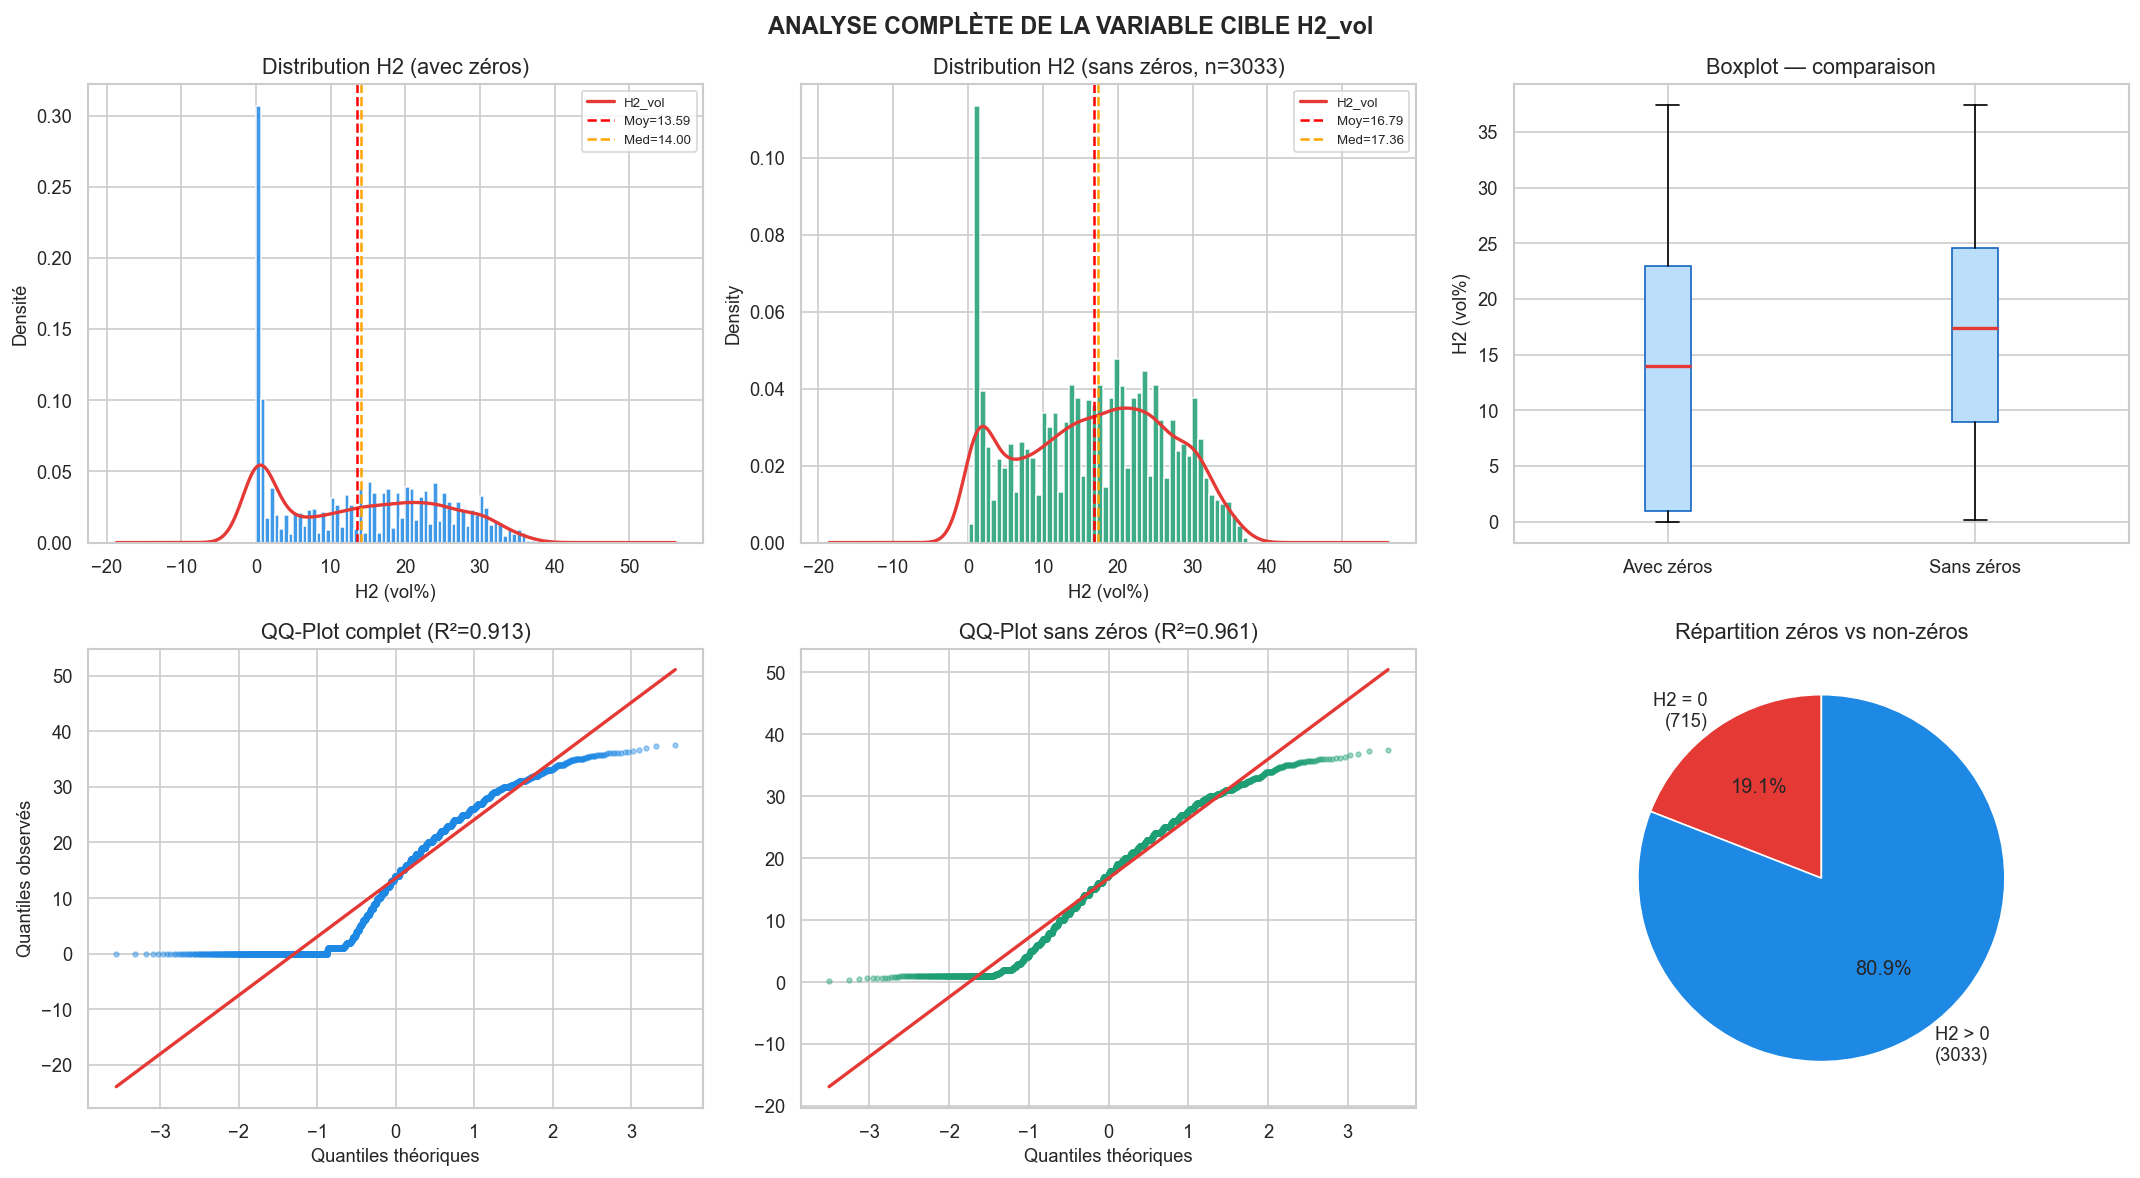

Skewness : 0.179  → proche normale
Kurtosis : -1.288
Outliers IQR : 0 (0.0%)
Zéros : 715 (19.1%) — ATTENTION pour la modélisation

💡 RECOMMANDATION : La distribution bimodale (pic en 0 + distribution H2>0)
   suggère d'envisager un modèle en 2 étapes :
   1. Classifier : H2=0 vs H2>0 (logistic/RandomForest)
   2. Régresser sur les observations H2>0 uniquement


In [6]:
h2 = data["H2_vol"]
h2_nz = h2[h2 > 0]   # sans les zéros

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Histogramme complet
axes[0,0].hist(h2, bins=60, color=C_H2, edgecolor="white", alpha=0.85, density=True)
h2.plot(kind="kde", ax=axes[0,0], color=C_WARN, linewidth=2)
axes[0,0].axvline(h2.mean(),   color="red",    ls="--", lw=1.5, label=f"Moy={h2.mean():.2f}")
axes[0,0].axvline(h2.median(), color="orange", ls="--", lw=1.5, label=f"Med={h2.median():.2f}")
axes[0,0].set_title("Distribution H2 (avec zéros)"); axes[0,0].legend(fontsize=8)
axes[0,0].set_xlabel("H2 (vol%)"); axes[0,0].set_ylabel("Densité")

# Histogramme sans zéros
axes[0,1].hist(h2_nz, bins=50, color=C_OK, edgecolor="white", alpha=0.85, density=True)
h2_nz.plot(kind="kde", ax=axes[0,1], color=C_WARN, linewidth=2)
axes[0,1].axvline(h2_nz.mean(),   color="red",    ls="--", lw=1.5, label=f"Moy={h2_nz.mean():.2f}")
axes[0,1].axvline(h2_nz.median(), color="orange", ls="--", lw=1.5, label=f"Med={h2_nz.median():.2f}")
axes[0,1].set_title(f"Distribution H2 (sans zéros, n={len(h2_nz)})"); axes[0,1].legend(fontsize=8)
axes[0,1].set_xlabel("H2 (vol%)")

# Boxplot
axes[0,2].boxplot([h2, h2_nz], labels=["Avec zéros", "Sans zéros"],
    patch_artist=True,
    boxprops=dict(facecolor="#bbdefb", color="#1565c0"),
    medianprops=dict(color=C_WARN, linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.4, markerfacecolor=C_WARN))
axes[0,2].set_title("Boxplot — comparaison"); axes[0,2].set_ylabel("H2 (vol%)")

# QQ-Plot complet
(osm, osr), (slope, intercept, r) = stats.probplot(h2, dist="norm")
axes[1,0].scatter(osm, osr, s=8, alpha=0.4, color=C_H2)
axes[1,0].plot(osm, slope*np.array(osm)+intercept, color=C_WARN, lw=2)
axes[1,0].set_title(f"QQ-Plot complet (R²={r**2:.3f})")
axes[1,0].set_xlabel("Quantiles théoriques"); axes[1,0].set_ylabel("Quantiles observés")

# QQ-Plot sans zéros
(osm2, osr2), (slope2, intercept2, r2) = stats.probplot(h2_nz, dist="norm")
axes[1,1].scatter(osm2, osr2, s=8, alpha=0.4, color=C_OK)
axes[1,1].plot(osm2, slope2*np.array(osm2)+intercept2, color=C_WARN, lw=2)
axes[1,1].set_title(f"QQ-Plot sans zéros (R²={r2**2:.3f})")
axes[1,1].set_xlabel("Quantiles théoriques")

# Bilan zéros
labels_z = [f"H2 = 0\n({(h2==0).sum()})", f"H2 > 0\n({(h2>0).sum()})"]
axes[1,2].pie([(h2==0).sum(), (h2>0).sum()], labels=labels_z,
              autopct="%1.1f%%", colors=[C_WARN, C_H2], startangle=90)
axes[1,2].set_title("Répartition zéros vs non-zéros")

plt.suptitle("ANALYSE COMPLÈTE DE LA VARIABLE CIBLE H2_vol", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

skew = h2.skew(); kurt = h2.kurtosis()
Q1, Q3 = h2.quantile(0.25), h2.quantile(0.75); IQR = Q3 - Q1
n_out = ((h2 < Q1-1.5*IQR)|(h2 > Q3+1.5*IQR)).sum()

print(f"Skewness : {skew:.3f}  → {'right-skewed' if skew>0.5 else 'left-skewed' if skew<-0.5 else 'proche normale'}")
print(f"Kurtosis : {kurt:.3f}")
print(f"Outliers IQR : {n_out} ({n_out/len(h2)*100:.1f}%)")
print(f"Zéros : {(h2==0).sum()} ({(h2==0).sum()/len(h2)*100:.1f}%) — ATTENTION pour la modélisation")
print(f"\n💡 RECOMMANDATION : La distribution bimodale (pic en 0 + distribution H2>0)")
print(f"   suggère d'envisager un modèle en 2 étapes :")
print(f"   1. Classifier : H2=0 vs H2>0 (logistic/RandomForest)")
print(f"   2. Régresser sur les observations H2>0 uniquement")

## 7. Pairplot — Relations entre toutes les features numériques (NOUVEAU v2)
Visualise d'un coup les corrélations, la multicolinéarité et la distribution de chaque variable.

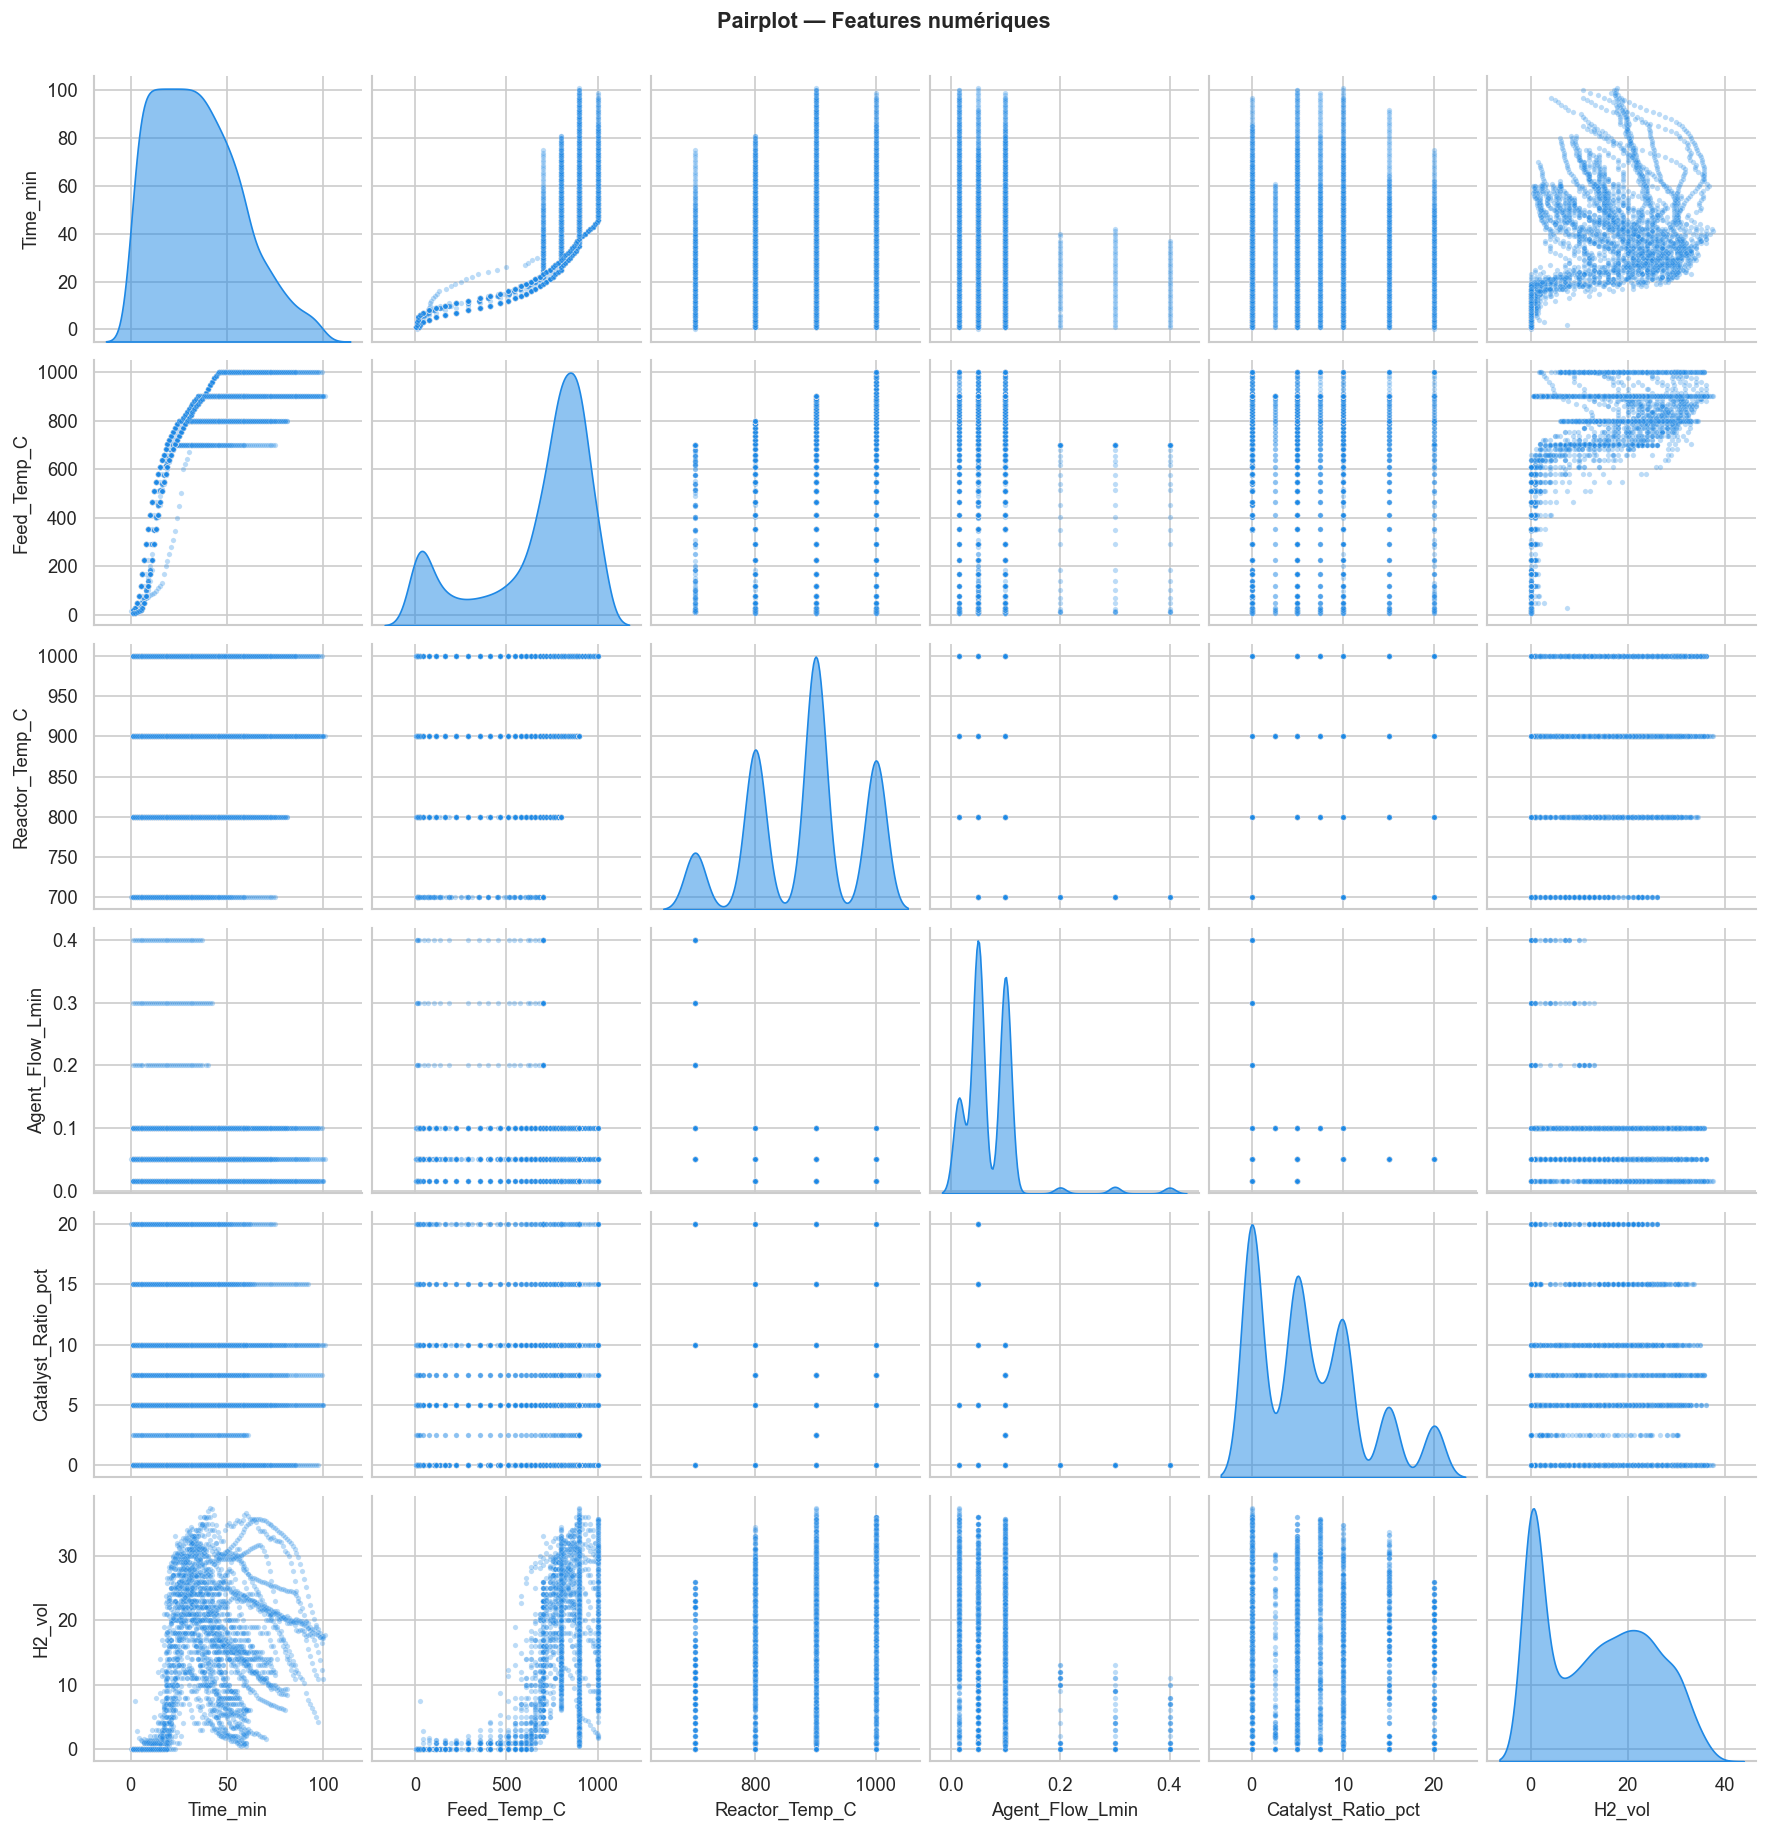

In [7]:
pairplot_cols = input_num + [TARGET]
pp = sns.pairplot(data[pairplot_cols], diag_kind="kde",
                  plot_kws={"alpha": 0.3, "s": 10, "color": C_H2},
                  diag_kws={"color": C_H2, "fill": True, "alpha": 0.5})
pp.fig.suptitle("Pairplot — Features numériques", y=1.02, fontsize=13, fontweight="bold")
plt.show()

## 8. Heatmap de corrélation — Focus H2

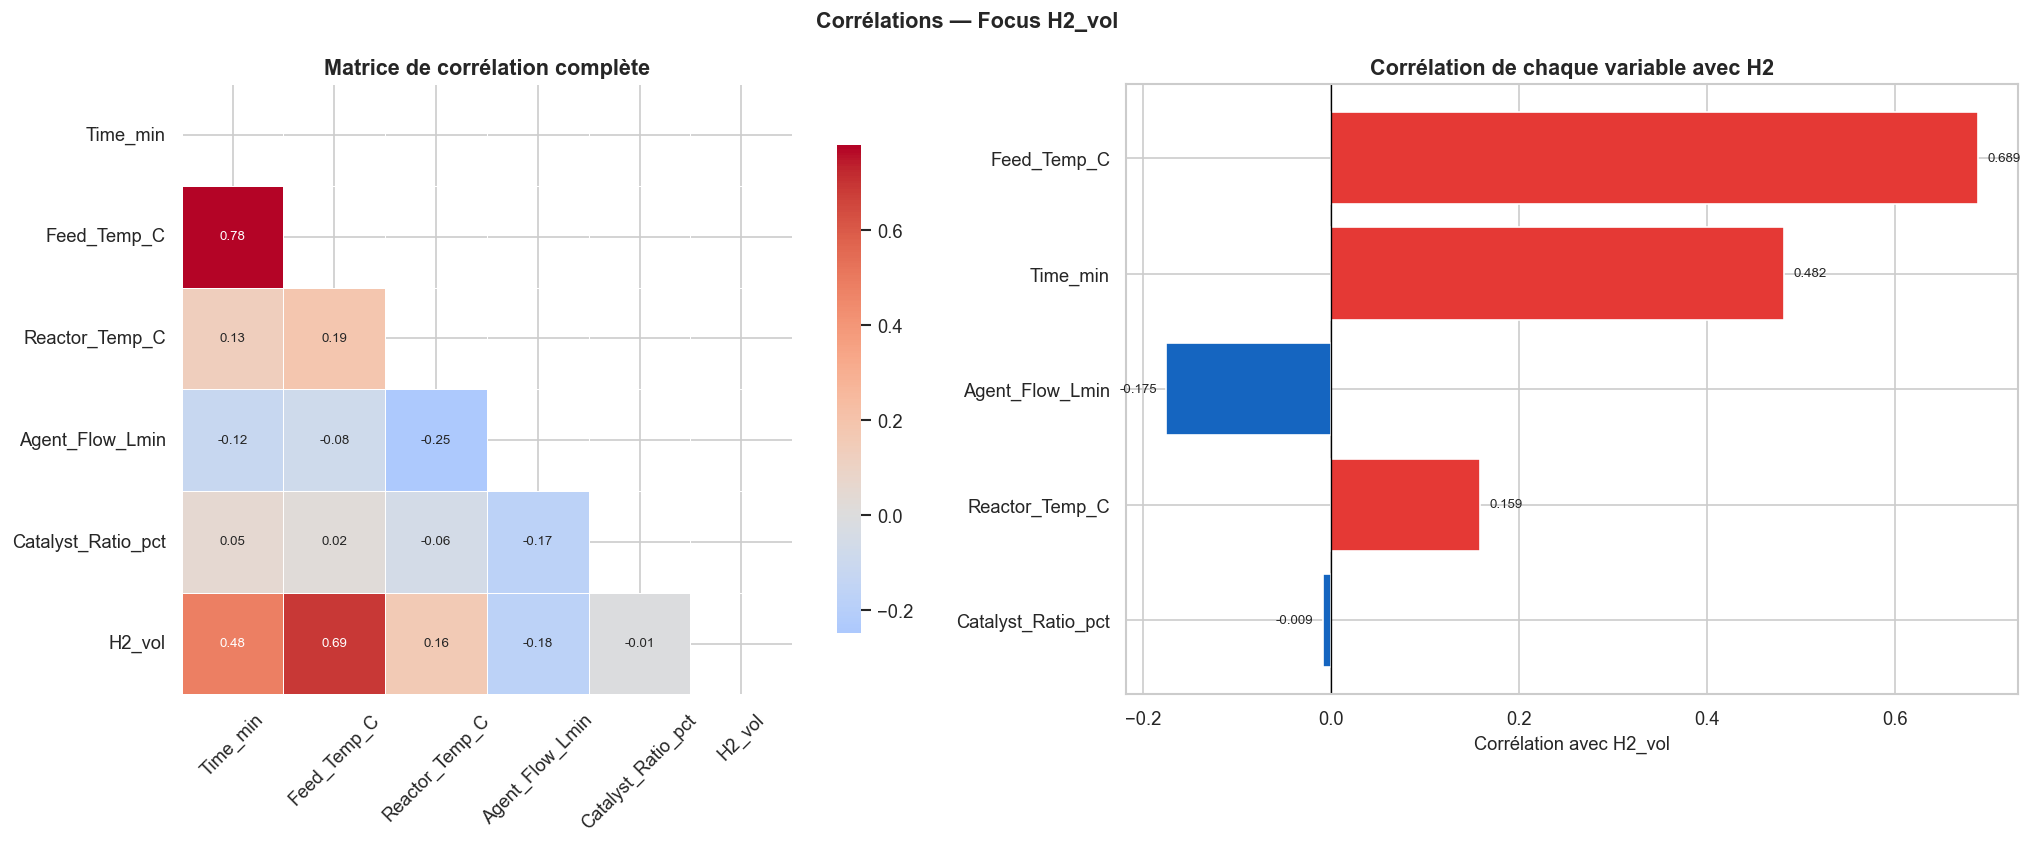

Top corrélations avec H2_vol :
  Feed_Temp_C                    +0.689  #############
  Time_min                       +0.482  #########
  Reactor_Temp_C                 +0.159  ###
  Catalyst_Ratio_pct             -0.009  
  Agent_Flow_Lmin                -0.175  ###


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

corr = data[num_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 8}, ax=axes[0])
axes[0].set_title("Matrice de corrélation complète", fontweight="bold")
axes[0].tick_params(axis="x", rotation=45)

corr_h2 = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)
colors_b = [C_WARN if v > 0 else "#1565c0" for v in corr_h2]
axes[1].barh(corr_h2.index, corr_h2.values, color=colors_b, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Corrélation avec H2_vol")
axes[1].set_title("Corrélation de chaque variable avec H2", fontweight="bold")
for i, (val, name) in enumerate(zip(corr_h2.values, corr_h2.index)):
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i, f"{val:.3f}",
                 va="center", ha="left" if val >= 0 else "right", fontsize=8)

plt.suptitle("Corrélations — Focus H2_vol", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Top corrélations avec H2_vol :")
for feat, val in corr[TARGET].drop(TARGET).sort_values(ascending=False).items():
    bar = "#" * int(abs(val)*20)
    print(f"  {feat:30s} {'+' if val>=0 else '-'}{abs(val):.3f}  {bar}")

## 9. Outliers — toutes les features numériques (NOUVEAU v2)
En v1, seul H2_vol était analysé. Ici on vérifie toutes les features.

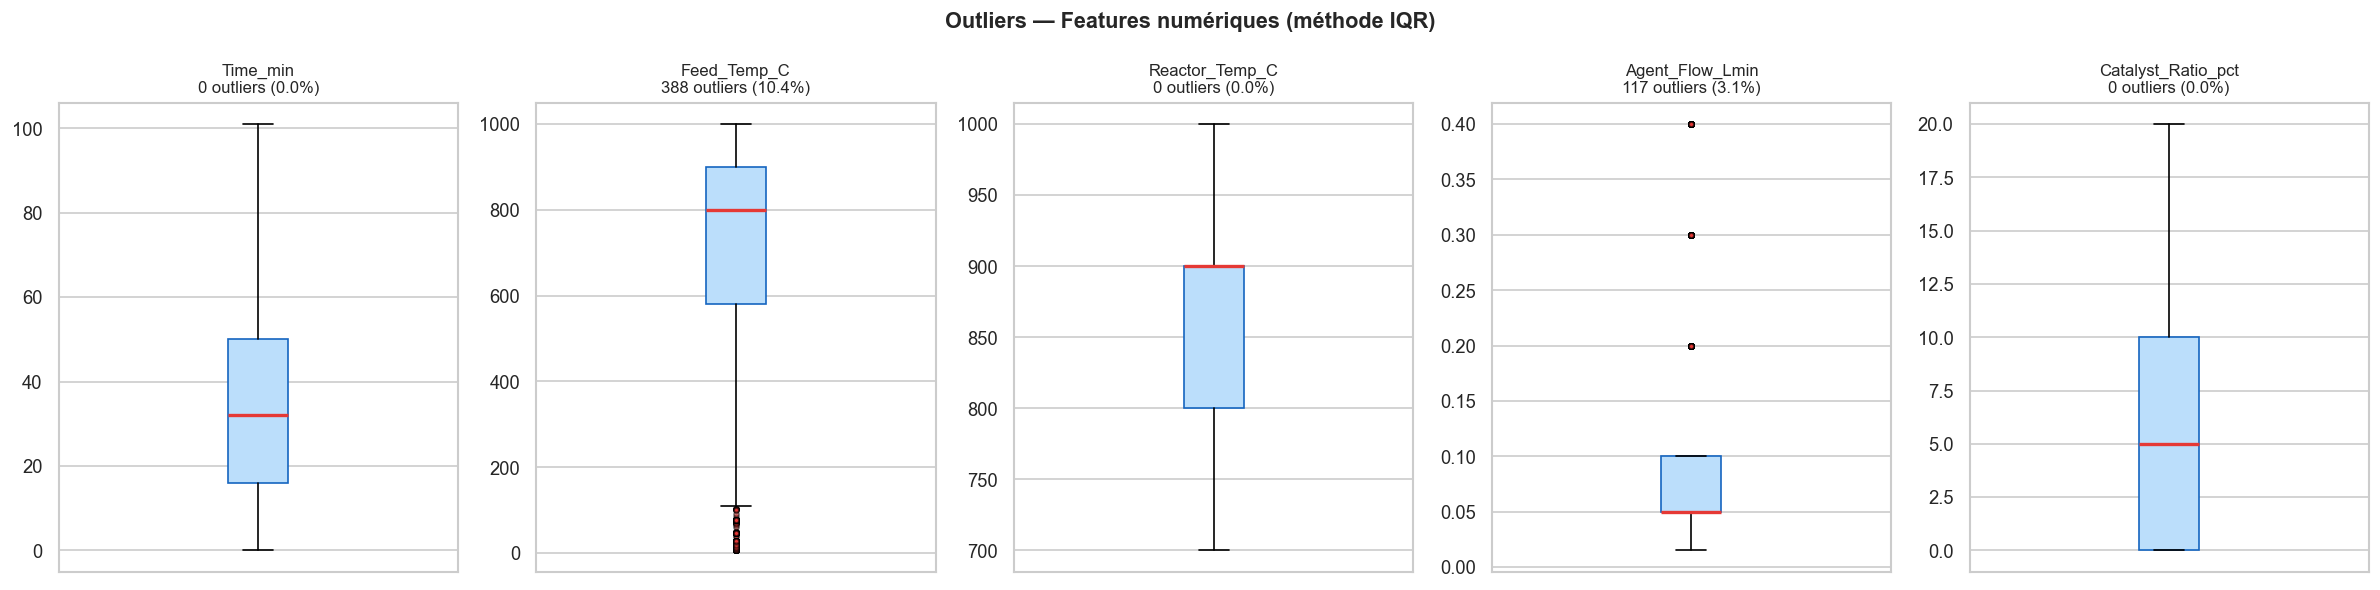


=== RAPPORT OUTLIERS ===
✅ Time_min                       :    0 (0.0%)  [-35.00 — 101.00]
⚠️ Feed_Temp_C                    :  388 (10.4%)  [102.50 — 1378.50]
✅ Reactor_Temp_C                 :    0 (0.0%)  [650.00 — 1050.00]
✅ Agent_Flow_Lmin                :  117 (3.1%)  [-0.03 — 0.18]
✅ Catalyst_Ratio_pct             :    0 (0.0%)  [-15.00 — 25.00]


In [9]:
fig, axes = plt.subplots(1, len(input_num), figsize=(4*len(input_num), 5))

outlier_report = {}
for ax, col in zip(axes, input_num):
    vals = data[col].dropna()
    Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((vals < Q1-1.5*IQR)|(vals > Q3+1.5*IQR)).sum()
    outlier_report[col] = {"count": n_out, "pct": n_out/len(vals)*100,
                           "lower": Q1-1.5*IQR, "upper": Q3+1.5*IQR}

    ax.boxplot(vals, patch_artist=True,
        boxprops=dict(facecolor="#bbdefb", color="#1565c0"),
        medianprops=dict(color=C_WARN, linewidth=2),
        flierprops=dict(marker="o", markersize=3, alpha=0.5, markerfacecolor=C_WARN))
    ax.set_title(f"{col}\n{n_out} outliers ({n_out/len(vals)*100:.1f}%)", fontsize=10)
    ax.set_xticks([])

plt.suptitle("Outliers — Features numériques (méthode IQR)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n=== RAPPORT OUTLIERS ===")
for col, info in outlier_report.items():
    flag = "⚠️" if info["pct"] > 5 else "✅"
    print(f"{flag} {col:30s} : {info['count']:4d} ({info['pct']:.1f}%)  "
          f"[{info['lower']:.2f} — {info['upper']:.2f}]")

## 10. Analyse temporelle — H2 par expérience (NOUVEAU v2)
**Correction critique v1 :** Les données temporelles sont maintenant analysées par run séparément.

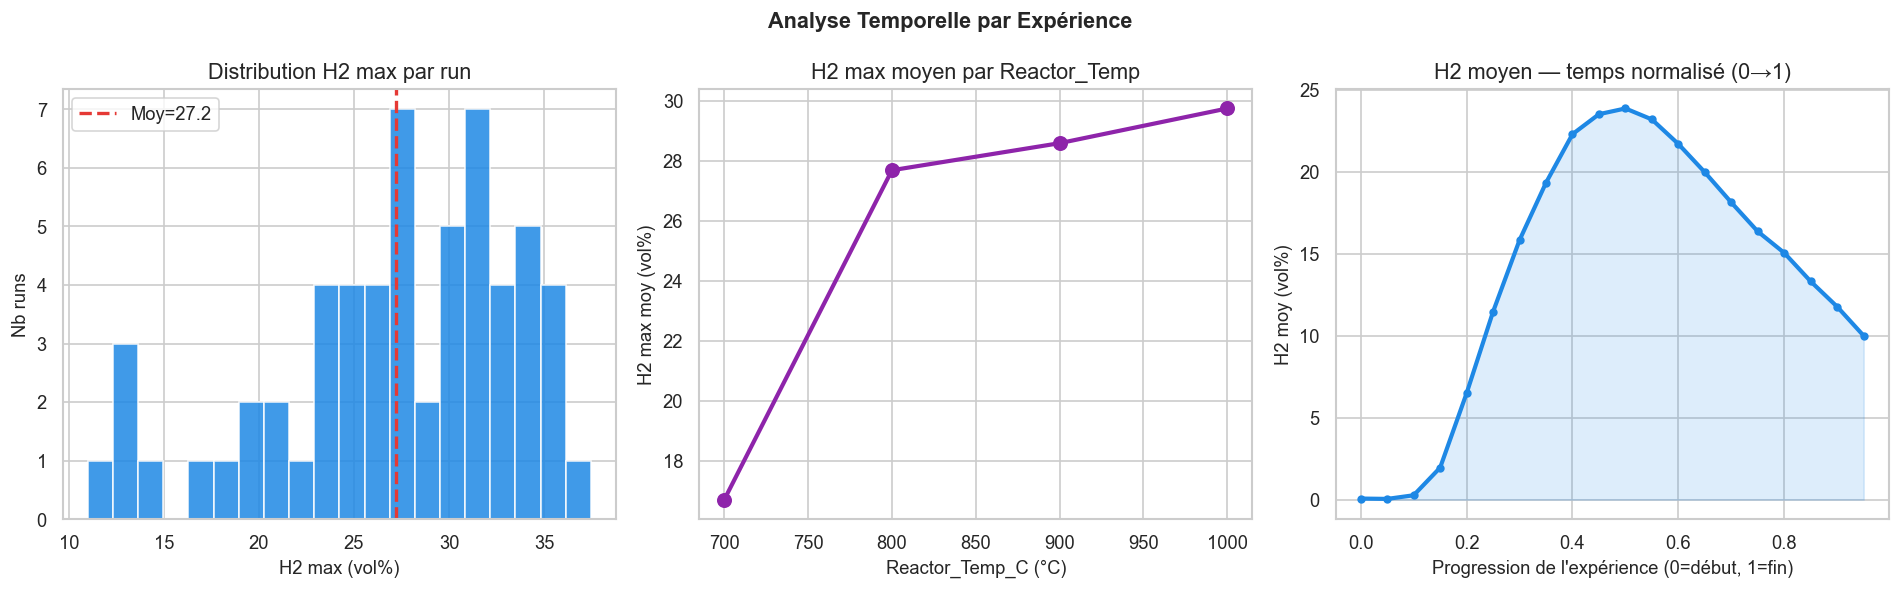

H2 max moyen par run    : 27.19 vol%
H2 max médian par run   : 28.00 vol%
Meilleur run (H2_max)   : 37.45 vol%


In [10]:
# H2 max par expérience
h2_max_per_run = (data.groupby("Experiment_ID")["H2_vol"]
                  .max().reset_index().rename(columns={"H2_vol": "H2_max"}))
run_meta = (data.groupby("Experiment_ID")
            [["Reactor_Temp_C","Agent_Type","Sample_Type","Catalyst_Type"]]
            .first().reset_index())
run_df = h2_max_per_run.merge(run_meta, on="Experiment_ID")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution des H2_max par run
axes[0].hist(run_df["H2_max"], bins=20, color=C_H2, edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution H2 max par run")
axes[0].set_xlabel("H2 max (vol%)"); axes[0].set_ylabel("Nb runs")
axes[0].axvline(run_df["H2_max"].mean(), color=C_WARN, ls="--", lw=2,
                label=f"Moy={run_df['H2_max'].mean():.1f}")
axes[0].legend()

# H2 max par Reactor_Temp
temp_h2 = run_df.groupby("Reactor_Temp_C")["H2_max"].mean()
axes[1].plot(temp_h2.index, temp_h2.values, color="#8e24aa", lw=2.5, marker="o", markersize=8)
axes[1].set_title("H2 max moyen par Reactor_Temp")
axes[1].set_xlabel("Reactor_Temp_C (°C)"); axes[1].set_ylabel("H2 max moy (vol%)")

# H2 moyen au cours du temps normalisé (tous runs)
# Normaliser le temps entre 0 et 1 par run
def norm_time(grp):
    grp = grp.sort_values("Time_min").copy()
    t_min, t_max = grp["Time_min"].min(), grp["Time_min"].max()
    if t_max > t_min:
        grp["Time_norm"] = (grp["Time_min"] - t_min) / (t_max - t_min)
    else:
        grp["Time_norm"] = 0.0
    return grp

data_norm = data.groupby("Experiment_ID", group_keys=False).apply(norm_time)
time_bins = pd.cut(data_norm["Time_norm"], bins=20, labels=False)
h2_by_normtime = data_norm.groupby(time_bins)["H2_vol"].mean()

axes[2].plot(h2_by_normtime.index / 20, h2_by_normtime.values,
             color=C_H2, lw=2.5, marker="o", markersize=4)
axes[2].fill_between(h2_by_normtime.index / 20, 0, h2_by_normtime.values,
                     alpha=0.15, color=C_H2)
axes[2].set_title("H2 moyen — temps normalisé (0→1)")
axes[2].set_xlabel("Progression de l'expérience (0=début, 1=fin)")
axes[2].set_ylabel("H2 moy (vol%)")

plt.suptitle("Analyse Temporelle par Expérience", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"H2 max moyen par run    : {run_df['H2_max'].mean():.2f} vol%")
print(f"H2 max médian par run   : {run_df['H2_max'].median():.2f} vol%")
print(f"Meilleur run (H2_max)   : {run_df['H2_max'].max():.2f} vol%")

## 11. Température vs H2

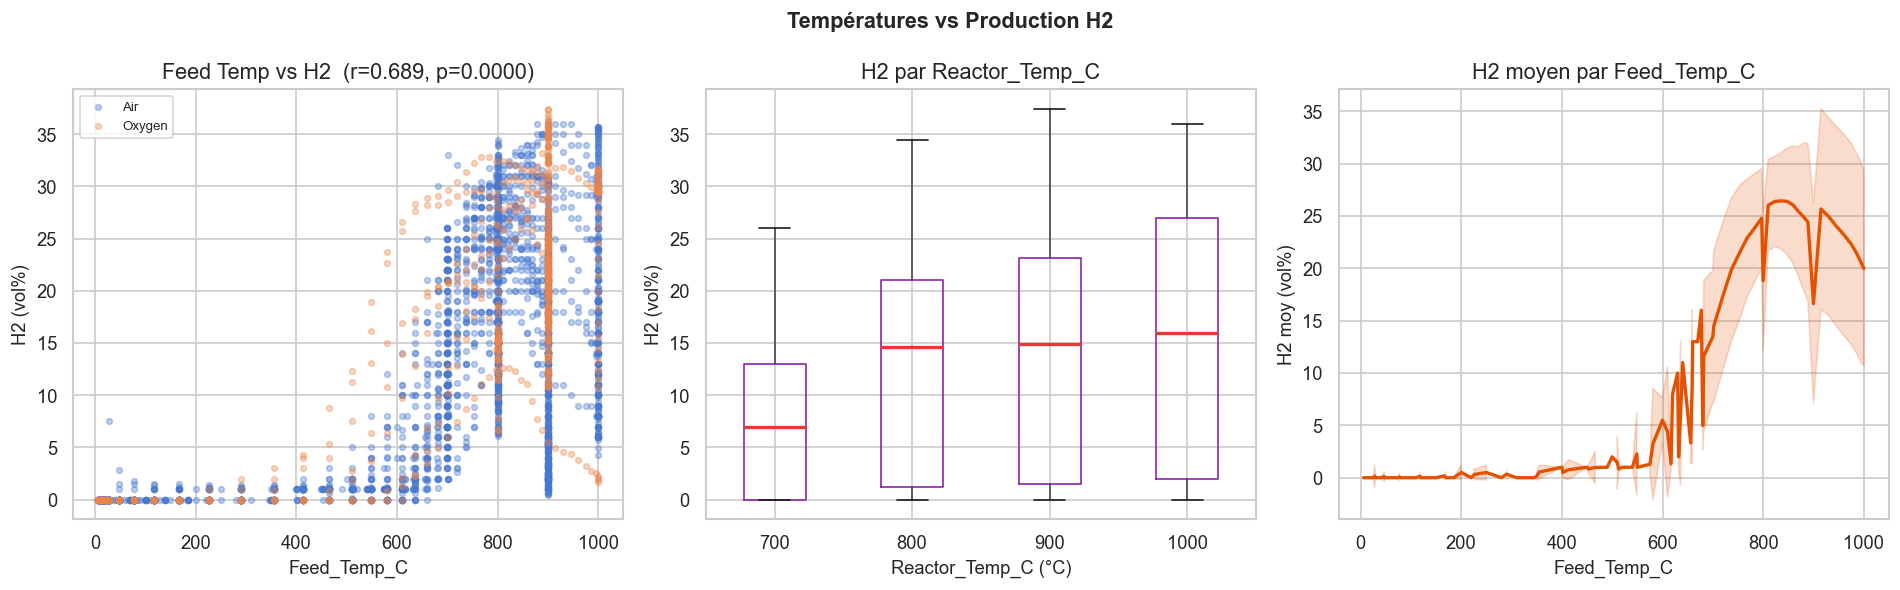

Corrélation Feed_Temp_C   → H2 : r=0.689  p=0.0000
Corrélation Reactor_Temp_C → H2 : r=0.159  p=0.0000


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Feed_Temp_C scatter
for agent, grp in data.groupby("Agent_Type"):
    axes[0].scatter(grp["Feed_Temp_C"], grp["H2_vol"], alpha=0.35, s=12, label=agent)
r, p = stats.pearsonr(data["Feed_Temp_C"], data["H2_vol"])
axes[0].set_title(f"Feed Temp vs H2  (r={r:.3f}, p={p:.4f})")
axes[0].set_xlabel("Feed_Temp_C"); axes[0].set_ylabel("H2 (vol%)"); axes[0].legend(fontsize=8)

# Reactor_Temp_C — boxplot (4 valeurs) AMÉLIORÉ v2
rt_order = sorted(data["Reactor_Temp_C"].unique())
data.boxplot(column="H2_vol", by="Reactor_Temp_C", ax=axes[1],
             boxprops=dict(color="#8e24aa"),
             medianprops=dict(color=C_WARN, linewidth=2),
             flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[1].set_title("H2 par Reactor_Temp_C (4 niveaux)")
axes[1].set_xlabel("Reactor_Temp_C (°C)"); axes[1].set_ylabel("H2 (vol%)")
plt.sca(axes[1]); plt.title("H2 par Reactor_Temp_C")

# H2 moyen par température (courbe)
temp_agg = data.groupby("Feed_Temp_C")["H2_vol"].agg(["mean","std"]).reset_index()
axes[2].plot(temp_agg["Feed_Temp_C"], temp_agg["mean"], color="#e65100", lw=2)
axes[2].fill_between(temp_agg["Feed_Temp_C"],
                     temp_agg["mean"]-temp_agg["std"],
                     temp_agg["mean"]+temp_agg["std"], alpha=0.2, color="#e65100")
axes[2].set_title("H2 moyen par Feed_Temp_C")
axes[2].set_xlabel("Feed_Temp_C"); axes[2].set_ylabel("H2 moy (vol%)")

plt.suptitle("Températures vs Production H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

r_rt, p_rt = stats.pearsonr(data["Reactor_Temp_C"], data["H2_vol"])
print(f"Corrélation Feed_Temp_C   → H2 : r={r:.3f}  p={p:.4f}")
print(f"Corrélation Reactor_Temp_C → H2 : r={r_rt:.3f}  p={p_rt:.4f}")

## 12. Agent Type vs H2

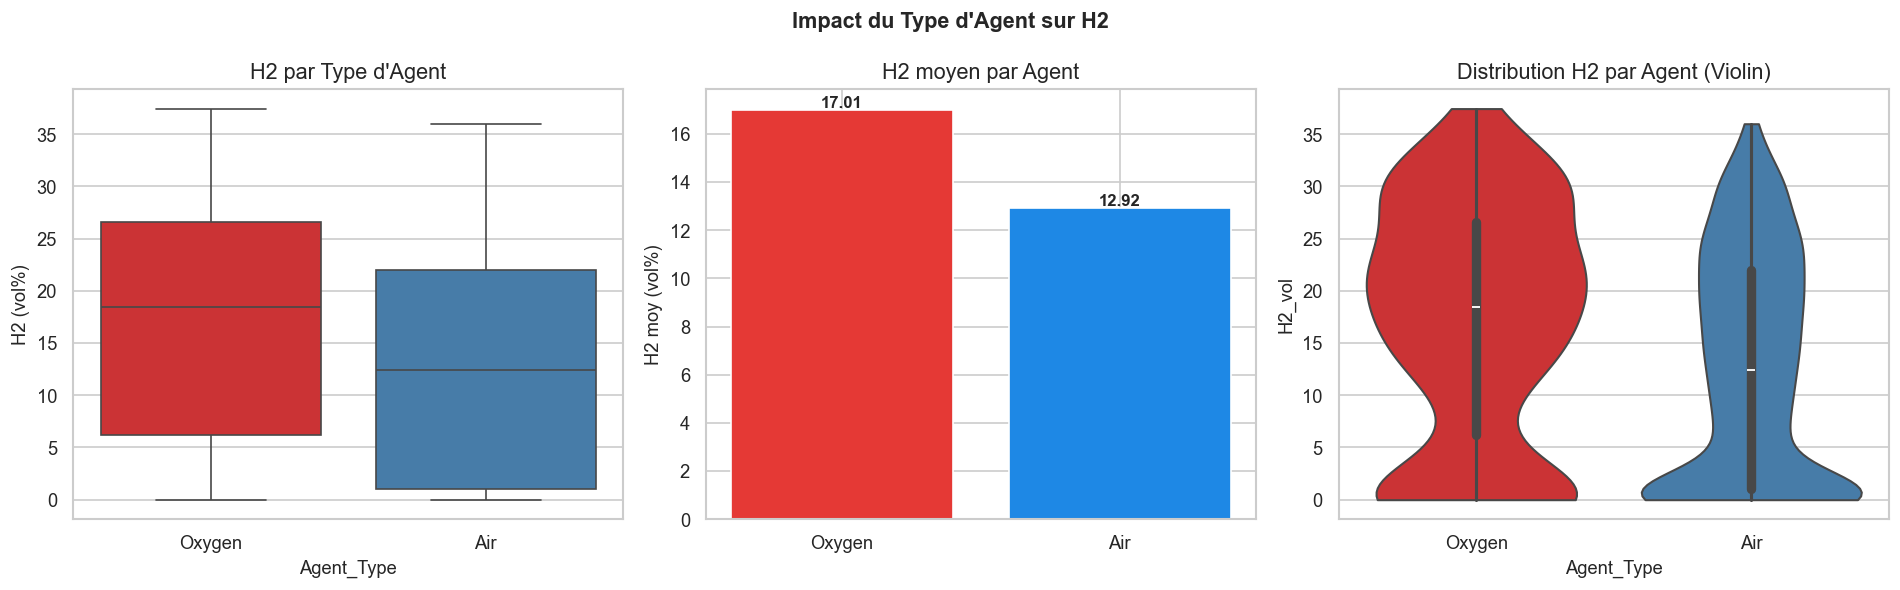

ANOVA Agent_Type → H2 : F=71.84, p=0.0000  (SIGNIFICATIF)
Agent_Type
Oxygen    17.008
Air       12.921


In [12]:
order_agent = data.groupby("Agent_Type")["H2_vol"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="Agent_Type", y="H2_vol", data=data, order=order_agent,
            palette="Set1", ax=axes[0],
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[0].set_title("H2 par Type d'Agent"); axes[0].set_ylabel("H2 (vol%)")

mean_agent = data.groupby("Agent_Type")["H2_vol"].mean().sort_values(ascending=False)
bars = axes[1].bar(mean_agent.index, mean_agent.values,
                   color=["#e53935","#1e88e5"][:len(mean_agent)], edgecolor="white")
axes[1].set_title("H2 moyen par Agent"); axes[1].set_ylabel("H2 moy (vol%)")
for bar, val in zip(bars, mean_agent.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

sns.violinplot(x="Agent_Type", y="H2_vol", data=data, order=order_agent,
               palette="Set1", inner="box", cut=0, ax=axes[2])
axes[2].set_title("Distribution H2 par Agent (Violin)")

plt.suptitle("Impact du Type d'Agent sur H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

groups_a = [grp["H2_vol"].values for _, grp in data.groupby("Agent_Type")]
f_a, p_a = stats.f_oneway(*groups_a)
print(f"ANOVA Agent_Type → H2 : F={f_a:.2f}, p={p_a:.4f}  ({'SIGNIFICATIF' if p_a<0.05 else 'non sign.'})")
print(mean_agent.round(3).to_string())

## 13. Catalyst Type vs H2 + Test Post-hoc Tukey (NOUVEAU v2)
**Ajout v2 :** L'ANOVA dit "il y a une différence", Tukey dit "laquelle paire est différente".

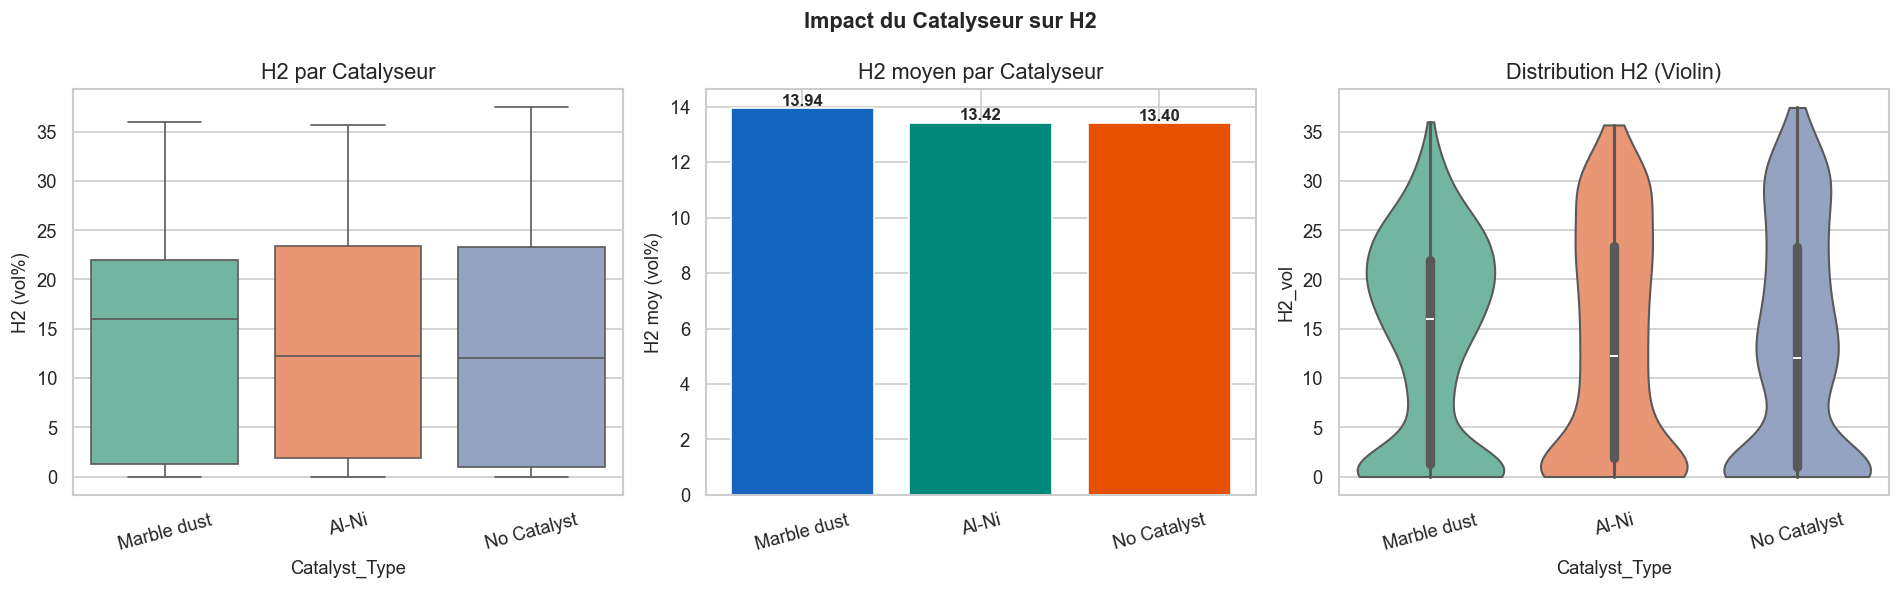

ANOVA Catalyst_Type → H2 : F=0.96, p=0.3812  (non sign.)
Meilleur : Marble dust  |  Moins efficace : No Catalyst

=== TEST POST-HOC TUKEY HSD ===
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
   group1      group2   meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
      Al-Ni Marble dust   0.5192 0.4534 -0.4956  1.534  False
      Al-Ni No Catalyst  -0.0177 0.9991  -1.056 1.0207  False
Marble dust No Catalyst  -0.5369 0.4526  -1.585 0.5112  False
-------------------------------------------------------------

💡 'reject=True' → les 2 catalyseurs sont significativement différents.


In [13]:
order_cat = data.groupby("Catalyst_Type")["H2_vol"].median().sort_values(ascending=False).index
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="Catalyst_Type", y="H2_vol", data=data, order=order_cat,
            palette="Set2", ax=axes[0],
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[0].set_title("H2 par Catalyseur"); axes[0].set_ylabel("H2 (vol%)")
axes[0].tick_params(axis="x", rotation=15)

mean_cat = data.groupby("Catalyst_Type")["H2_vol"].mean().sort_values(ascending=False)
bars = axes[1].bar(mean_cat.index, mean_cat.values,
                   color=PALETTE[:len(mean_cat)], edgecolor="white")
axes[1].set_title("H2 moyen par Catalyseur"); axes[1].set_ylabel("H2 moy (vol%)")
axes[1].tick_params(axis="x", rotation=15)
for bar, val in zip(bars, mean_cat.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

sns.violinplot(x="Catalyst_Type", y="H2_vol", data=data, order=order_cat,
               palette="Set2", inner="box", cut=0, ax=axes[2])
axes[2].set_title("Distribution H2 (Violin)"); axes[2].tick_params(axis="x", rotation=15)

plt.suptitle("Impact du Catalyseur sur H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

groups_c = [grp["H2_vol"].values for _, grp in data.groupby("Catalyst_Type")]
f_c, p_c = stats.f_oneway(*groups_c)
print(f"ANOVA Catalyst_Type → H2 : F={f_c:.2f}, p={p_c:.4f}  ({'SIGNIFICATIF' if p_c<0.05 else 'non sign.'})")
print(f"Meilleur : {mean_cat.index[0]}  |  Moins efficace : {mean_cat.index[-1]}")

# ── Test Post-hoc Tukey (NOUVEAU v2) ─────────────────────────────────────────
print("\n=== TEST POST-HOC TUKEY HSD ===")
tukey = pairwise_tukeyhsd(data["H2_vol"], data["Catalyst_Type"])
print(tukey.summary())
print("\n💡 'reject=True' → les 2 catalyseurs sont significativement différents.")

## 14. Sample Type vs H2

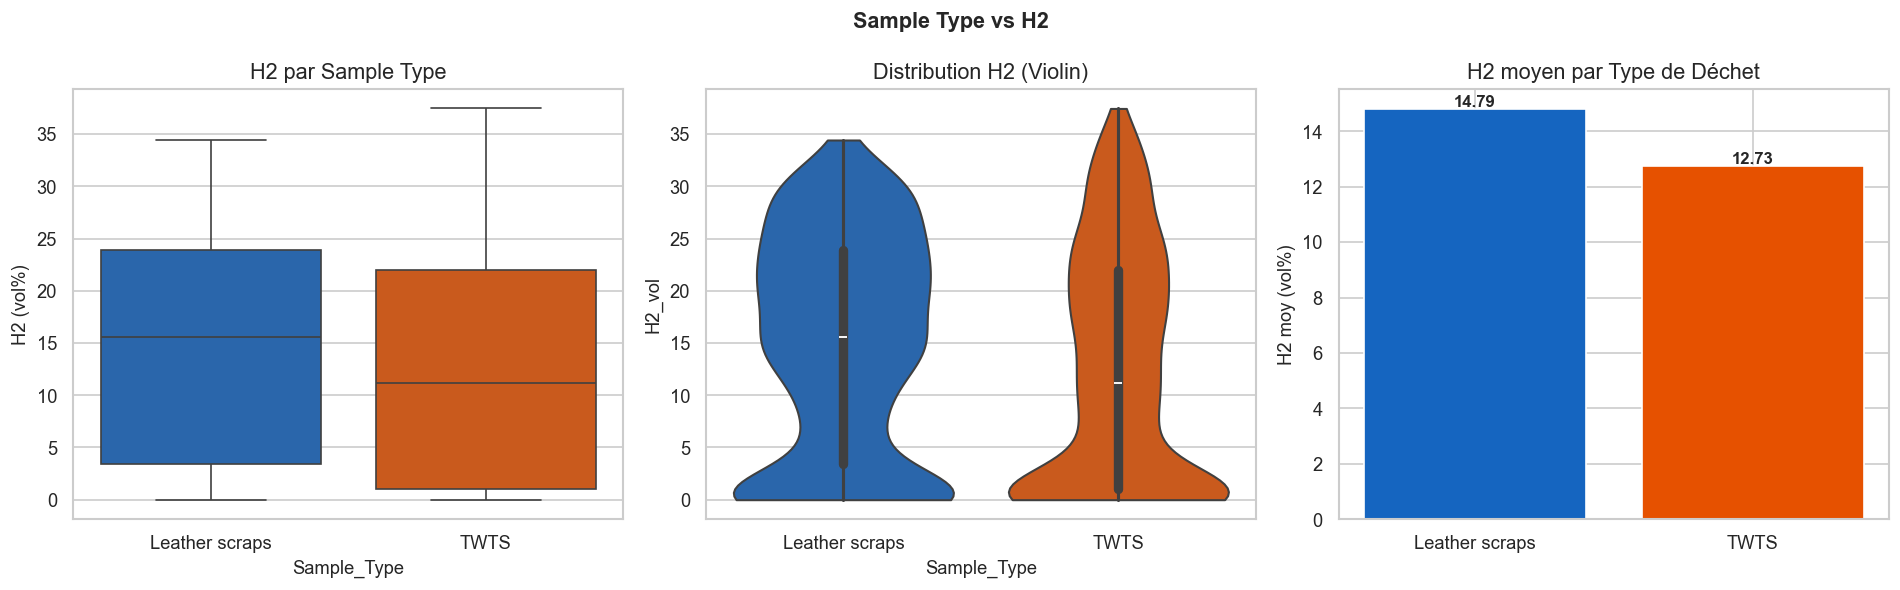

Mann-Whitney : p=0.0000  (SIGNIFICATIF)
Sample_Type
Leather scraps    14.787
TWTS              12.730


In [14]:
order_s = data.groupby("Sample_Type")["H2_vol"].median().sort_values(ascending=False).index
pal_s = ["#1565c0","#e65100"][:len(order_s)]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x="Sample_Type", y="H2_vol", data=data, order=order_s,
            palette=pal_s, ax=axes[0],
            flierprops=dict(marker="o", markersize=3, alpha=0.4))
axes[0].set_title("H2 par Sample Type"); axes[0].set_ylabel("H2 (vol%)")

sns.violinplot(x="Sample_Type", y="H2_vol", data=data, order=order_s,
               palette=pal_s, inner="box", cut=0, ax=axes[1])
axes[1].set_title("Distribution H2 (Violin)")

mean_s = data.groupby("Sample_Type")["H2_vol"].mean().sort_values(ascending=False)
bars = axes[2].bar(mean_s.index, mean_s.values, color=pal_s, edgecolor="white")
axes[2].set_title("H2 moyen par Type de Déchet"); axes[2].set_ylabel("H2 moy (vol%)")
for bar, val in zip(bars, mean_s.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Sample Type vs H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

groups_s = [grp["H2_vol"].values for _, grp in data.groupby("Sample_Type")]
stat, p_s = stats.mannwhitneyu(*groups_s, alternative="two-sided")
print(f"Mann-Whitney : p={p_s:.4f}  ({'SIGNIFICATIF' if p_s<0.05 else 'non sign.'})")
print(mean_s.round(3).to_string())

## 15. Débit Agent & Ratio Catalyseur vs H2

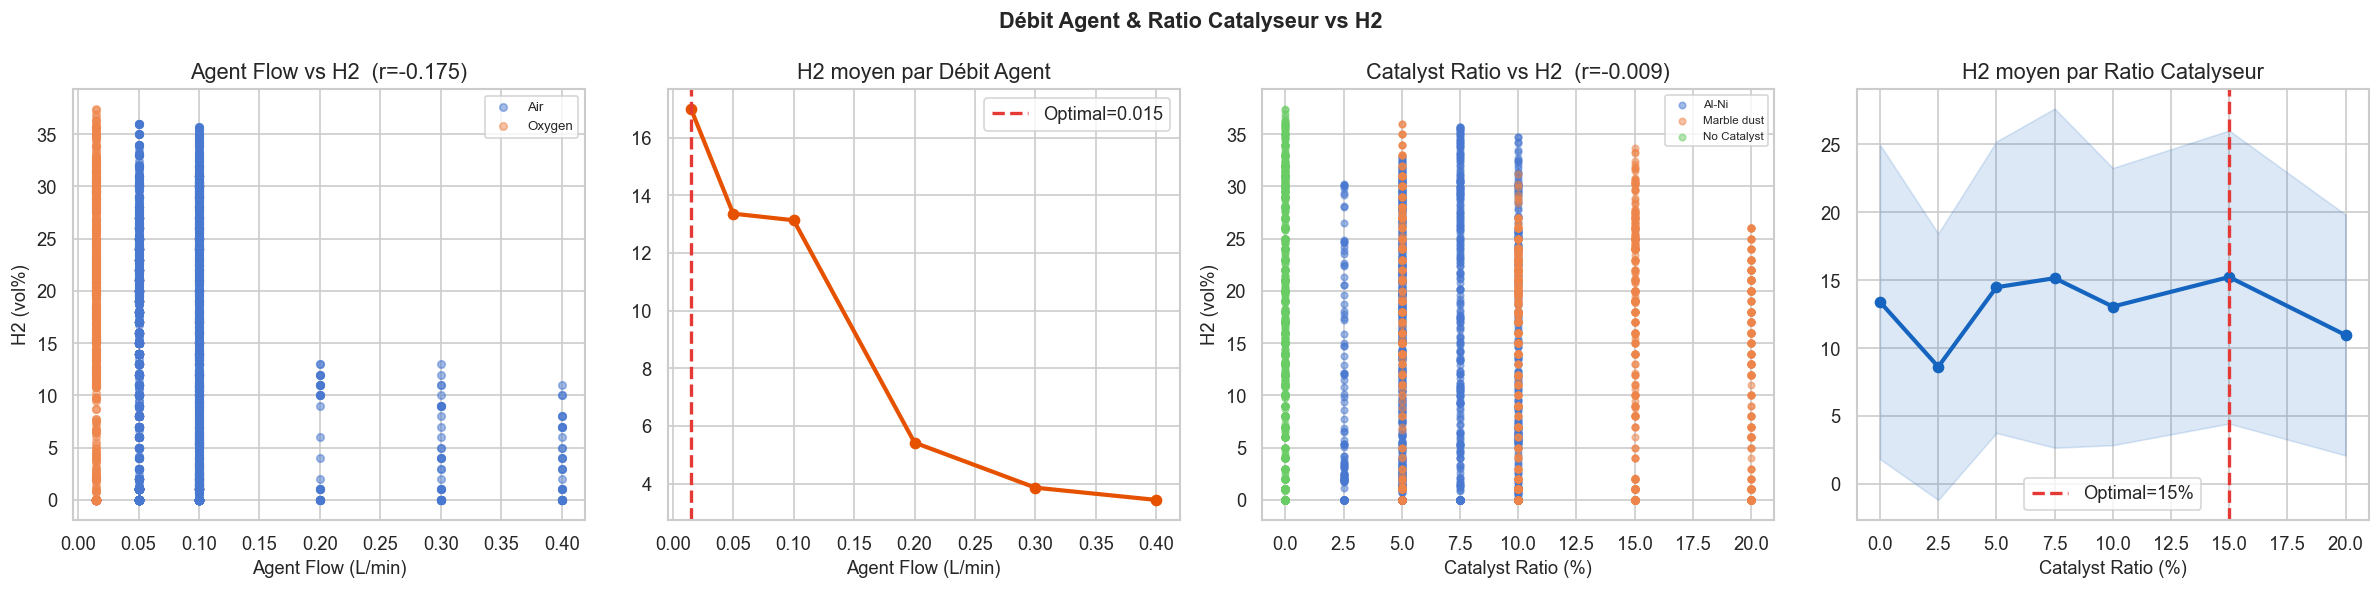

Corrélation Agent_Flow     → H2 : r=-0.175
Corrélation Catalyst_Ratio → H2 : r=-0.009
Débit optimal H2 : 0.015 L/min  |  Ratio optimal : 15%


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Agent Flow scatter
for agent, grp in data.groupby("Agent_Type"):
    axes[0].scatter(grp["Agent_Flow_Lmin"], grp["H2_vol"], alpha=0.5, s=20, label=agent)
r_af, _ = stats.pearsonr(data["Agent_Flow_Lmin"], data["H2_vol"])
axes[0].set_title(f"Agent Flow vs H2  (r={r_af:.3f})")
axes[0].set_xlabel("Agent Flow (L/min)"); axes[0].set_ylabel("H2 (vol%)"); axes[0].legend(fontsize=8)

# Agent Flow moyen
flow_agg = data.groupby("Agent_Flow_Lmin")["H2_vol"].mean().reset_index()
opt_flow = flow_agg.loc[flow_agg["H2_vol"].idxmax(), "Agent_Flow_Lmin"]
axes[1].plot(flow_agg["Agent_Flow_Lmin"], flow_agg["H2_vol"],
             color="#e65100", lw=2.5, marker="o", markersize=6)
axes[1].axvline(opt_flow, color=C_WARN, lw=2, ls="--", label=f"Optimal={opt_flow:.3f}")
axes[1].set_title("H2 moyen par Débit Agent"); axes[1].set_xlabel("Agent Flow (L/min)"); axes[1].legend()

# Catalyst Ratio scatter
for cat, grp in data.groupby("Catalyst_Type"):
    axes[2].scatter(grp["Catalyst_Ratio_pct"], grp["H2_vol"], alpha=0.5, s=15, label=cat)
r_cr, _ = stats.pearsonr(data["Catalyst_Ratio_pct"], data["H2_vol"])
axes[2].set_title(f"Catalyst Ratio vs H2  (r={r_cr:.3f})")
axes[2].set_xlabel("Catalyst Ratio (%)"); axes[2].set_ylabel("H2 (vol%)"); axes[2].legend(fontsize=7)

# Catalyst Ratio moyen
ratio_agg = data.groupby("Catalyst_Ratio_pct")["H2_vol"].agg(["mean","std"]).reset_index()
opt_r = ratio_agg.loc[ratio_agg["mean"].idxmax(), "Catalyst_Ratio_pct"]
axes[3].plot(ratio_agg["Catalyst_Ratio_pct"], ratio_agg["mean"],
             color="#1565c0", lw=2.5, marker="o", markersize=6)
axes[3].fill_between(ratio_agg["Catalyst_Ratio_pct"],
                     ratio_agg["mean"]-ratio_agg["std"],
                     ratio_agg["mean"]+ratio_agg["std"], alpha=0.15, color="#1565c0")
axes[3].axvline(opt_r, color=C_WARN, lw=2, ls="--", label=f"Optimal={opt_r:.0f}%")
axes[3].set_title("H2 moyen par Ratio Catalyseur"); axes[3].set_xlabel("Catalyst Ratio (%)"); axes[3].legend()

plt.suptitle("Débit Agent & Ratio Catalyseur vs H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print(f"Corrélation Agent_Flow     → H2 : r={r_af:.3f}")
print(f"Corrélation Catalyst_Ratio → H2 : r={r_cr:.3f}")
print(f"Débit optimal H2 : {opt_flow:.3f} L/min  |  Ratio optimal : {opt_r:.0f}%")

## 16. Analyse combinée — Interactions

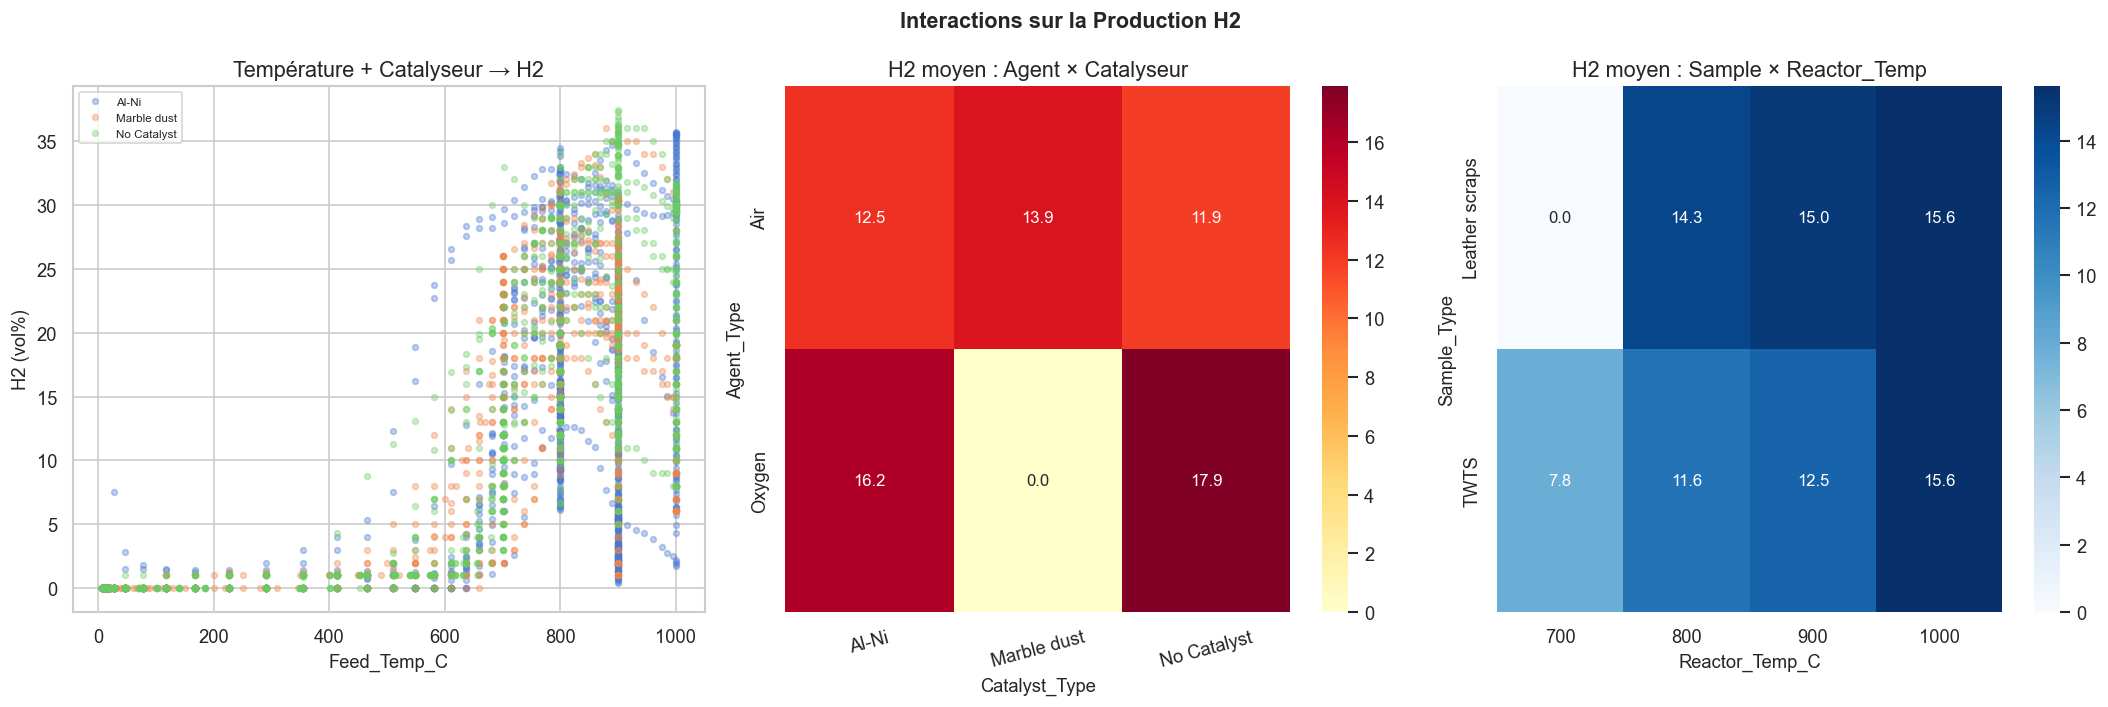

MEILLEURE COMBINAISON GLOBALE H2 :
  Agent      : Oxygen
  Catalyseur : No Catalyst
  Déchet     : TWTS
  H2 moy     : 21.16 vol%


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Température + Catalyseur
for cat, grp in data.groupby("Catalyst_Type"):
    axes[0].scatter(grp["Feed_Temp_C"], grp["H2_vol"], alpha=0.35, s=12, label=cat)
axes[0].set_title("Température + Catalyseur → H2")
axes[0].set_xlabel("Feed_Temp_C"); axes[0].set_ylabel("H2 (vol%)"); axes[0].legend(fontsize=7)

# Heatmap Agent × Catalyst
pivot_ac = data.groupby(["Agent_Type","Catalyst_Type"])["H2_vol"].mean().unstack(fill_value=0)
sns.heatmap(pivot_ac, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=axes[1], annot_kws={"size": 10})
axes[1].set_title("H2 moyen : Agent × Catalyseur")
axes[1].tick_params(axis="x", rotation=15)

# Heatmap Sample × Reactor_Temp
pivot_sr = data.groupby(["Sample_Type","Reactor_Temp_C"])["H2_vol"].mean().unstack(fill_value=0)
sns.heatmap(pivot_sr, annot=True, fmt=".1f", cmap="Blues",
            ax=axes[2], annot_kws={"size": 10})
axes[2].set_title("H2 moyen : Sample × Reactor_Temp")

plt.suptitle("Interactions sur la Production H2", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

combo = data.groupby(["Agent_Type","Catalyst_Type","Sample_Type"])["H2_vol"].mean()
best = combo.idxmax()
print(f"MEILLEURE COMBINAISON GLOBALE H2 :")
print(f"  Agent      : {best[0]}")
print(f"  Catalyseur : {best[1]}")
print(f"  Déchet     : {best[2]}")
print(f"  H2 moy     : {combo.max():.2f} vol%")

## 17. Top 15 expériences H2 (BUG CORRIGÉ v2)
**Correction :** La v1 comparait top15 vs top15 (les deux colonnes étaient identiques). Corrigé ici.

In [17]:
top15 = (data.nlargest(15, "H2_vol")
         [["Time_min","Feed_Temp_C","Reactor_Temp_C",
           "Agent_Type","Agent_Flow_Lmin","Sample_Type",
           "Catalyst_Type","Catalyst_Ratio_pct","H2_vol"]]
         .reset_index(drop=True))
print("TOP 15 expériences — plus haute production H2 :")
display(top15.round(2))

top15_idx  = data.nlargest(15, "H2_vol").index
rest_idx   = data.index.difference(top15_idx)

print("\nPattern Top15 vs Reste (variables numériques) :")
compare_n = pd.DataFrame({
    "Top15 H2 max"  : data.loc[top15_idx, input_num].mean().round(2),
    "Reste dataset" : data.loc[rest_idx,  input_num].mean().round(2),    # CORRIGÉ
    "Différence"    : (data.loc[top15_idx, input_num].mean()
                     - data.loc[rest_idx,  input_num].mean()).round(2),
})
display(compare_n)

print("\nPattern catégoriel Top15 :")
for col in input_cat:
    if col == "Experiment_ID":
        continue
    print(f"  {col:20s} — Top15: {data.loc[top15_idx,col].mode()[0]:20s} | Global: {data[col].mode()[0]}")

TOP 15 expériences — plus haute production H2 :


,Time_min,Feed_Temp_C,Reactor_Temp_C,Agent_Type,Agent_Flow_Lmin,Sample_Type,Catalyst_Type,Catalyst_Ratio_pct,H2_vol
0,41,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,37.45
1,42,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,37.27
2,40,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,36.89
3,60,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,36.64
4,43,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,36.36
5,59,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,36.27
6,61,900,900,Oxygen,0.02,TWTS,No Catalyst,0.0,36.19
7,38,900,1000,Air,0.05,TWTS,No Catalyst,0.0,36.00
8,39,915,1000,Air,0.05,TWTS,No Catalyst,0.0,36.00
9,40,930,1000,Air,0.05,TWTS,No Catalyst,0.0,36.00



Pattern Top15 vs Reste (variables numériques) :


,Top15 H2 max,Reste dataset,Différence
Time_min,45.33,34.60,10.73
Feed_Temp_C,904.60,676.67,227.93
Reactor_Temp_C,940.00,879.64,60.36
Agent_Flow_Lmin,0.03,0.07,-0.04
Catalyst_Ratio_pct,0.67,6.36,-5.69



Pattern catégoriel Top15 :
  Agent_Type           — Top15: Oxygen               | Global: Air
  Sample_Type          — Top15: TWTS                 | Global: TWTS
  Catalyst_Type        — Top15: No Catalyst          | Global: Al-Ni


## 18. Feature Engineering (NOUVEAU v2)
Nouvelles variables construites à partir des features existantes — potentiellement très utiles pour les modèles ML.

=== CORRÉLATIONS NOUVELLES FEATURES AVEC H2_vol ===


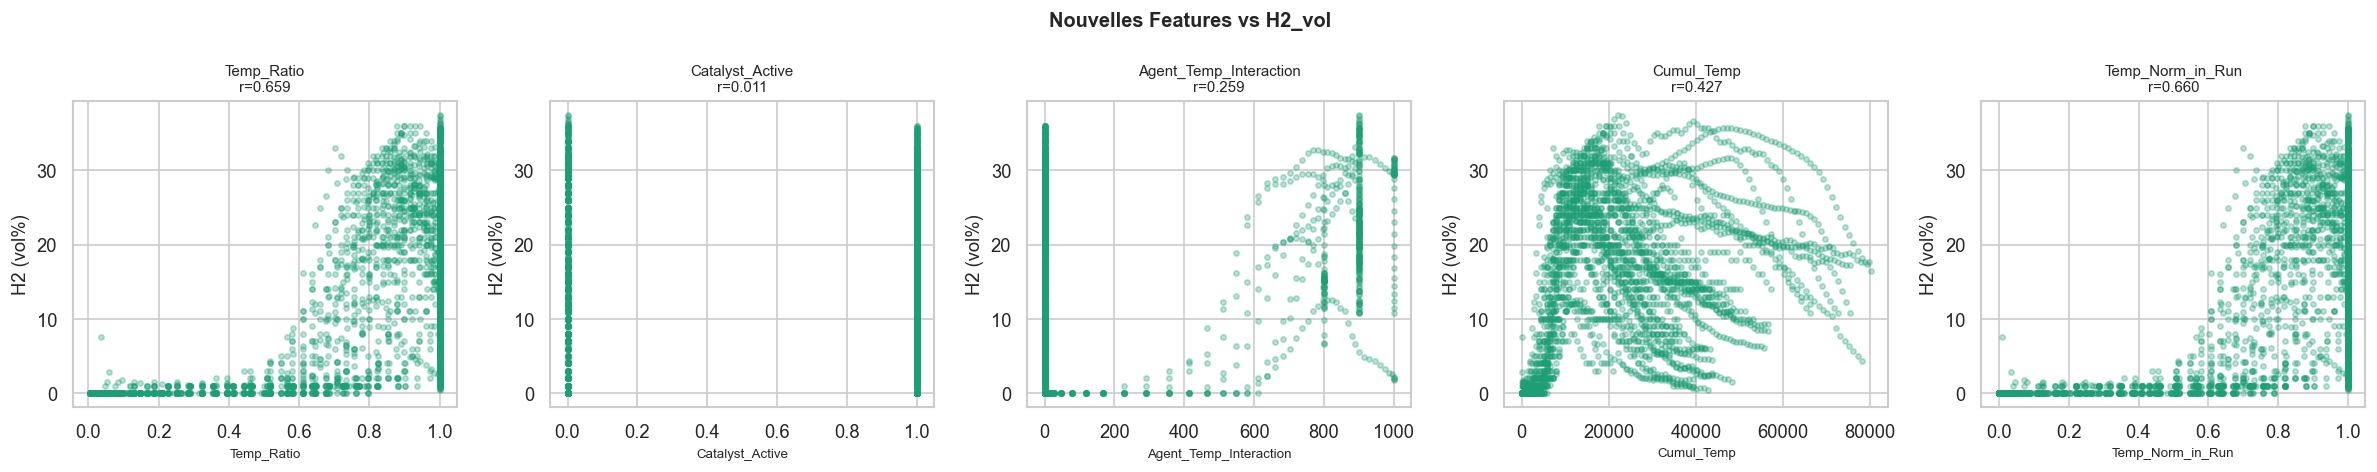

🟢 Temp_Ratio                     : r=+0.659  p=0.0000
⚪ Catalyst_Active                : r=+0.011  p=0.4839
🟡 Agent_Temp_Interaction         : r=+0.259  p=0.0000
🟢 Cumul_Temp                     : r=+0.427  p=0.0000
🟢 Temp_Norm_in_Run               : r=+0.660  p=0.0000


In [18]:
data_fe = data.copy()

# 1. Ratio thermique
data_fe["Temp_Ratio"] = data_fe["Feed_Temp_C"] / (data_fe["Reactor_Temp_C"] + 1e-6)

# 2. Catalyseur actif (booléen)
data_fe["Catalyst_Active"] = (data_fe["Catalyst_Type"] != "No Catalyst").astype(int)

# 3. Interaction Agent × Température
data_fe["Agent_Temp_Interaction"] = (
    data_fe["Agent_Type"].map({"Air": 0, "Oxygen": 1}).fillna(0)
    * data_fe["Feed_Temp_C"]
)

# 4. Énergie thermique cumulée par run
data_fe = data_fe.sort_values(["Experiment_ID","Time_min"])
data_fe["Cumul_Temp"] = data_fe.groupby("Experiment_ID")["Feed_Temp_C"].cumsum()

# 5. Température normalisée dans le run (0=début chaud, 1=fin)
data_fe["Temp_Norm_in_Run"] = (
    data_fe.groupby("Experiment_ID")["Feed_Temp_C"]
    .transform(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6))
)

new_features = ["Temp_Ratio","Catalyst_Active","Agent_Temp_Interaction","Cumul_Temp","Temp_Norm_in_Run"]

# Corrélations des nouvelles features avec H2_vol
print("=== CORRÉLATIONS NOUVELLES FEATURES AVEC H2_vol ===")
fig, axes = plt.subplots(1, len(new_features), figsize=(4*len(new_features), 4))
for ax, feat in zip(axes, new_features):
    ax.scatter(data_fe[feat], data_fe["H2_vol"], alpha=0.3, s=10, color=C_OK)
    r, p = stats.pearsonr(data_fe[feat].dropna(), data_fe["H2_vol"].dropna())
    ax.set_title(f"{feat}\nr={r:.3f}", fontsize=9)
    ax.set_xlabel(feat, fontsize=8); ax.set_ylabel("H2 (vol%)")
plt.suptitle("Nouvelles Features vs H2_vol", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

for feat in new_features:
    r, p = stats.pearsonr(data_fe[feat].dropna(), data_fe["H2_vol"].dropna())
    flag = "🟢" if abs(r) > 0.3 else "🟡" if abs(r) > 0.1 else "⚪"
    print(f"{flag} {feat:30s} : r={r:+.3f}  p={p:.4f}")

## 19. Feature Importance — Pearson + RandomForest (AMÉLIORÉ v2)
**Ajout v2 :** RandomForest capture les relations non-linéaires que Pearson ne peut pas voir.

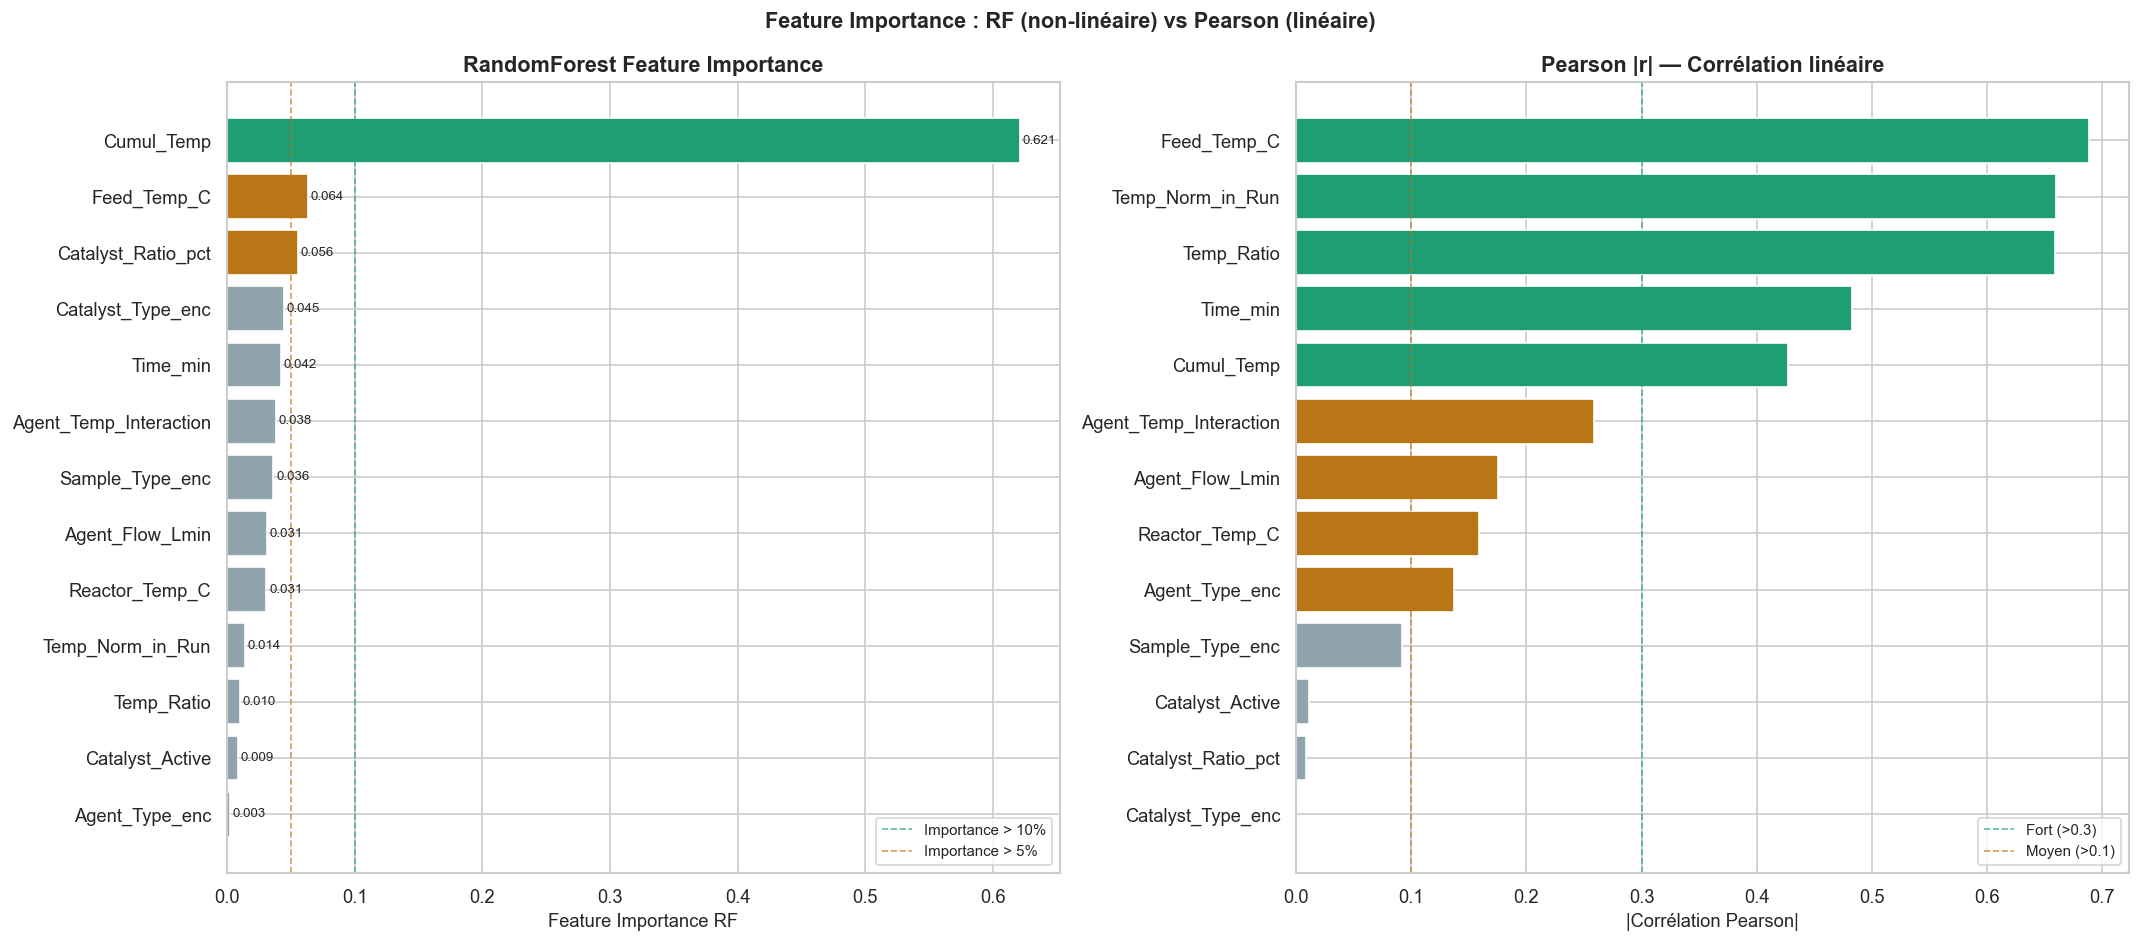

Top 8 features — RandomForest :
  Cumul_Temp                     : 0.621  [FORT]
  Feed_Temp_C                    : 0.064  [MOYEN]
  Catalyst_Ratio_pct             : 0.056  [MOYEN]
  Catalyst_Type_enc              : 0.045  [FAIBLE]
  Time_min                       : 0.042  [FAIBLE]
  Agent_Temp_Interaction         : 0.038  [FAIBLE]
  Sample_Type_enc                : 0.036  [FAIBLE]
  Agent_Flow_Lmin                : 0.031  [FAIBLE]


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# ── Préparer les données pour RF ─────────────────────────────────────────────
df_rf = data_fe.copy()
le = LabelEncoder()
for col in ["Agent_Type","Sample_Type","Catalyst_Type"]:
    df_rf[col+"_enc"] = le.fit_transform(df_rf[col])

feature_cols_rf = (input_num
                   + ["Agent_Type_enc","Sample_Type_enc","Catalyst_Type_enc"]
                   + new_features)
feature_cols_rf = [c for c in feature_cols_rf if c in df_rf.columns and c != "Experiment_ID"]

X = df_rf[feature_cols_rf].fillna(0)
y = df_rf[TARGET]

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

imp_rf = pd.Series(rf.feature_importances_, index=feature_cols_rf).sort_values(ascending=True)

# ── Pearson |r| ───────────────────────────────────────────────────────────────
pearson_imp = {}
for col in feature_cols_rf:
    r, _ = stats.pearsonr(X[col].dropna(), y[X[col].notna()])
    pearson_imp[col] = abs(r)
imp_pearson = pd.Series(pearson_imp).sort_values(ascending=True)

# ── Comparaison visuelle ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors_rf = [C_OK if v > 0.1 else "#BA7517" if v > 0.05 else "#90a4ae" for v in imp_rf.values]
axes[0].barh(imp_rf.index, imp_rf.values, color=colors_rf, edgecolor="white")
axes[0].axvline(0.1, color=C_OK, ls="--", lw=1, alpha=0.7, label="Importance > 10%")
axes[0].axvline(0.05, color="#BA7517", ls="--", lw=1, alpha=0.7, label="Importance > 5%")
axes[0].set_xlabel("Feature Importance RF"); axes[0].set_title("RandomForest Feature Importance", fontweight="bold")
axes[0].legend(fontsize=9)
for bar, val in zip(axes[0].patches, imp_rf.values):
    axes[0].text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=8)

colors_p = [C_OK if v > 0.3 else "#BA7517" if v > 0.1 else "#90a4ae" for v in imp_pearson.values]
axes[1].barh(imp_pearson.index, imp_pearson.values, color=colors_p, edgecolor="white")
axes[1].axvline(0.3, color=C_OK,       ls="--", lw=1, alpha=0.7, label="Fort (>0.3)")
axes[1].axvline(0.1, color="#BA7517",  ls="--", lw=1, alpha=0.7, label="Moyen (>0.1)")
axes[1].set_xlabel("|Corrélation Pearson|"); axes[1].set_title("Pearson |r| — Corrélation linéaire", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Feature Importance : RF (non-linéaire) vs Pearson (linéaire)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 8 features — RandomForest :")
for feat, val in imp_rf.sort_values(ascending=False).head(8).items():
    niv = "FORT" if val > 0.1 else "MOYEN" if val > 0.05 else "FAIBLE"
    print(f"  {feat:30s} : {val:.3f}  [{niv}]")

## 20. Normalité des features numériques (NOUVEAU v2)
Aide à choisir entre normalisation **StandardScaler** (si normale) vs **MinMaxScaler** (si asymétrique),
et valide si Pearson r est approprié ou si Spearman serait mieux.

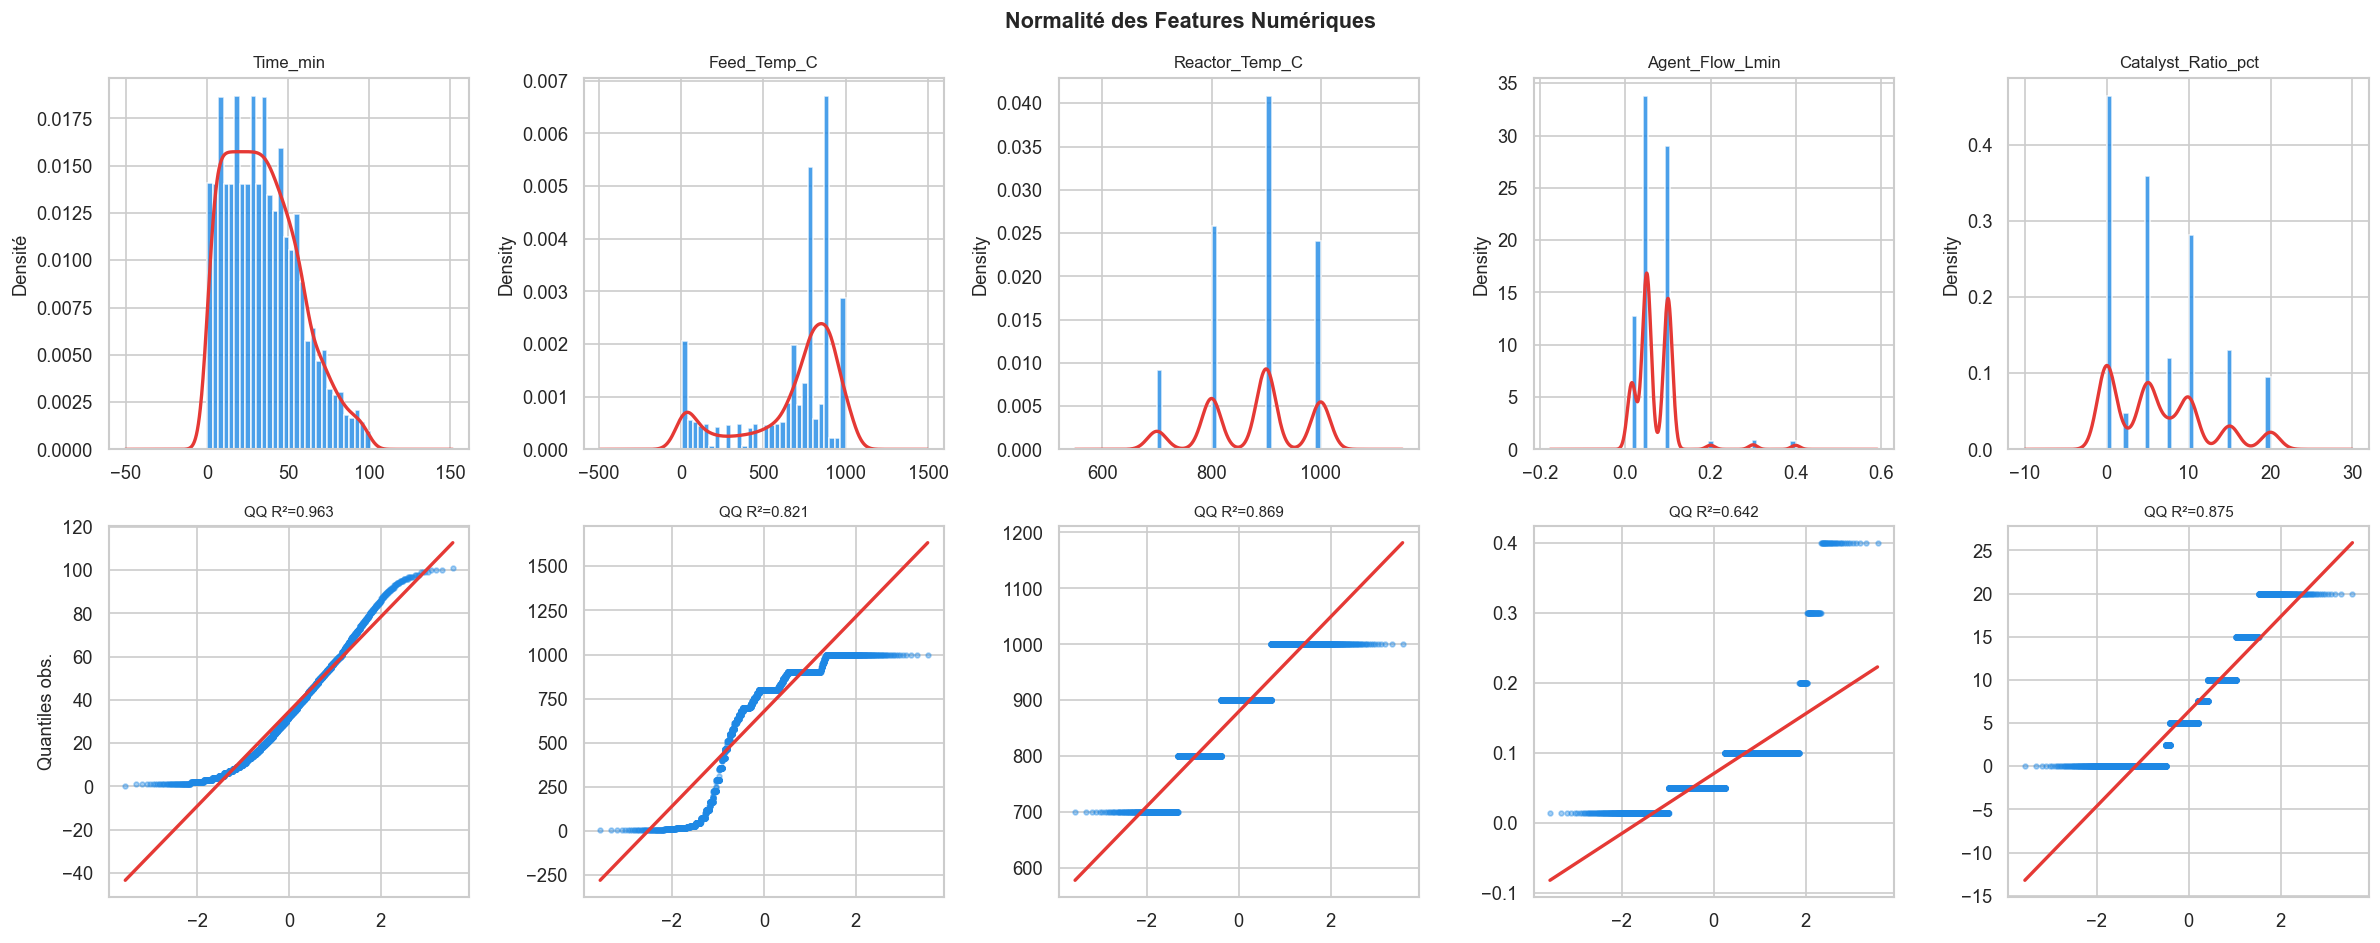

=== RÉSULTAT SHAPIRO-WILK ===
Feature                           Shapiro p   Skewness    QQ R²      Scaler recommandé
------------------------------------------------------------------------------------------
⚠️ Time_min                           0.0000      0.556    0.963  MinMaxScaler / RobustScaler
⚠️ Feed_Temp_C                        0.0000     -1.151    0.821  MinMaxScaler / RobustScaler
⚠️ Reactor_Temp_C                     0.0000     -0.327    0.869  MinMaxScaler / RobustScaler
⚠️ Agent_Flow_Lmin                    0.0000      3.220    0.642  MinMaxScaler / RobustScaler
✅ Catalyst_Ratio_pct                 1.0000      0.731    0.875  StandardScaler


In [20]:
fig, axes = plt.subplots(2, len(input_num), figsize=(4*len(input_num), 8))

normality_results = {}
for j, col in enumerate(input_num):
    vals = data[col].dropna()

    # Histogramme + KDE
    axes[0,j].hist(vals, bins=30, color=C_H2, edgecolor="white", alpha=0.8, density=True)
    vals.plot(kind="kde", ax=axes[0,j], color=C_WARN, lw=2)
    axes[0,j].set_title(col, fontsize=10)
    if j == 0: axes[0,j].set_ylabel("Densité")

    # QQ-plot
    (osm, osr), (slope, intercept, r) = stats.probplot(vals, dist="norm")
    axes[1,j].scatter(osm, osr, s=8, alpha=0.4, color=C_H2)
    axes[1,j].plot(osm, slope*np.array(osm)+intercept, color=C_WARN, lw=2)
    axes[1,j].set_title(f"QQ R²={r**2:.3f}", fontsize=9)
    if j == 0: axes[1,j].set_ylabel("Quantiles obs.")

    stat_sw, p_sw = shapiro(vals[:500])  # Shapiro sur max 500 obs
    skew_val = vals.skew()
    normality_results[col] = {"shapiro_p": p_sw, "skew": skew_val, "R2_qq": r**2}

plt.suptitle("Normalité des Features Numériques", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("=== RÉSULTAT SHAPIRO-WILK ===")
print(f"{'Feature':30s} {'Shapiro p':>12} {'Skewness':>10} {'QQ R²':>8} {'Scaler recommandé':>22}")
print("-"*90)
for col, info in normality_results.items():
    is_normal = info["shapiro_p"] > 0.05
    scaler = "StandardScaler" if is_normal else "MinMaxScaler / RobustScaler"
    flag = "✅" if is_normal else "⚠️"
    print(f"{flag} {col:28s} {info['shapiro_p']:12.4f} {info['skew']:10.3f} {info['R2_qq']:8.3f}  {scaler}")

## 21. Détection finale des outliers — H2_vol

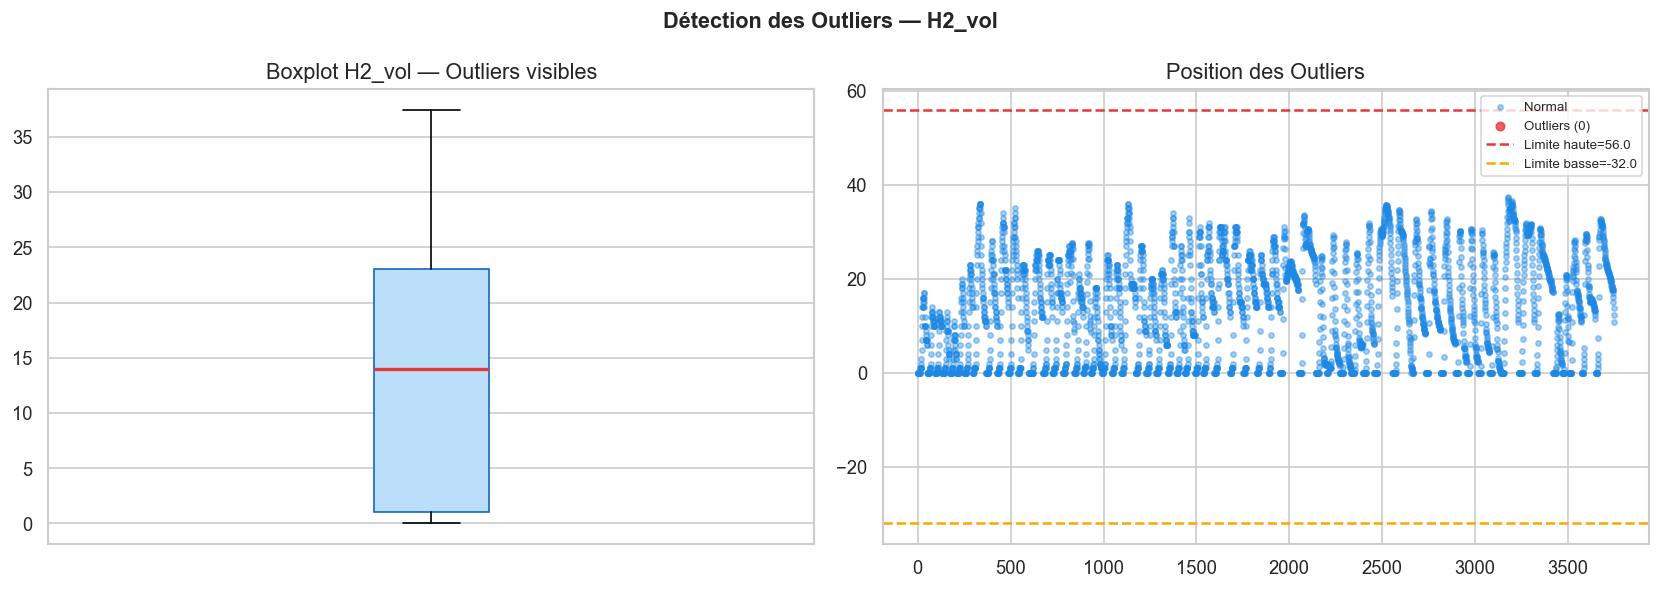

Outliers H2_vol (IQR) : 0 (0.0%)
Limite basse=-32.00  |  Limite haute=56.00

💡 Ces outliers sont de VRAIES valeurs d'expérience (pas erreurs de mesure).
   → Les conserver pour la modélisation.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(data["H2_vol"].dropna(), vert=True, patch_artist=True,
    boxprops=dict(facecolor="#bbdefb", color="#1565c0"),
    medianprops=dict(color=C_WARN, linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.6, markerfacecolor=C_WARN))
axes[0].set_title("Boxplot H2_vol — Outliers visibles"); axes[0].set_xticks([])

Q1, Q3 = data["H2_vol"].quantile(0.25), data["H2_vol"].quantile(0.75)
IQR = Q3 - Q1; lower = Q1 - 1.5*IQR; upper = Q3 + 1.5*IQR
mask_out = (data["H2_vol"] < lower)|(data["H2_vol"] > upper)

axes[1].scatter(data.index[~mask_out], data["H2_vol"][~mask_out],
                alpha=0.4, s=10, color=C_H2, label="Normal")
axes[1].scatter(data.index[mask_out], data["H2_vol"][mask_out],
                alpha=0.8, s=25, color=C_WARN, label=f"Outliers ({mask_out.sum()})")
axes[1].axhline(upper, color=C_WARN, lw=1.5, ls="--", label=f"Limite haute={upper:.1f}")
axes[1].axhline(lower, color="orange", lw=1.5, ls="--", label=f"Limite basse={lower:.1f}")
axes[1].set_title("Position des Outliers"); axes[1].legend(fontsize=8)

plt.suptitle("Détection des Outliers — H2_vol", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Outliers H2_vol (IQR) : {mask_out.sum()} ({mask_out.sum()/len(data)*100:.1f}%)")
print(f"Limite basse={lower:.2f}  |  Limite haute={upper:.2f}")
print(f"\n💡 Ces outliers sont de VRAIES valeurs d'expérience (pas erreurs de mesure).")
print(f"   → Les conserver pour la modélisation.")

## 22. Récapitulatif — Recommandations Preprocessing
Ce qui doit être fait avant la modélisation.

In [22]:
print("="*70)
print("RÉCAPITULATIF EDA — RECOMMANDATIONS POUR LE PREPROCESSING")
print("="*70)

mean_cat   = data.groupby("Catalyst_Type")["H2_vol"].mean()
mean_agent = data.groupby("Agent_Type")["H2_vol"].mean()
mean_s     = data.groupby("Sample_Type")["H2_vol"].mean()
r_t, _     = stats.pearsonr(data["Feed_Temp_C"], data["H2_vol"])
imp_rf_sorted = imp_rf.sort_values(ascending=False)

print(f"\nDataset : {data.shape[0]} observations | {data.shape[1]} colonnes | {data['Experiment_ID'].nunique()} runs")
print(f"H2_vol : moy={data['H2_vol'].mean():.2f}  max={data['H2_vol'].max():.2f}  std={data['H2_vol'].std():.2f}")
print(f"Zéros  : {(data['H2_vol']==0).sum()} ({(data['H2_vol']==0).sum()/len(data)*100:.1f}%)")

print("\n──────────────────────────────────────────────────────────────────────")
print("INSIGHTS CLÉS :")
print(f"  Meilleur catalyseur  : {mean_cat.idxmax()} ({mean_cat.max():.2f} vol%)")
print(f"  Meilleur agent       : {mean_agent.idxmax()} ({mean_agent.max():.2f} vol%)")
print(f"  Meilleur déchet      : {mean_s.idxmax()} ({mean_s.max():.2f} vol%)")
print(f"  Feature la + impactante (RF) : {imp_rf_sorted.index[0]} ({imp_rf_sorted.iloc[0]:.3f})")
print(f"  Corrélation Feed_Temp → H2  : r={r_t:.3f}")

print("\n──────────────────────────────────────────────────────────────────────")
print("CHECKLIST PREPROCESSING :")
print("  ✅ 1. Strip espaces — FAIT dans section 3")
print("  ✅ 2. H2 négatifs → 0 — FAIT dans section 3")
print("  ✅ 3. Experiment_ID créé — FAIT dans section 4")
print("  ⏳ 4. Encoder les catégorielles :")
print("       → OneHotEncoder(Agent_Type, Sample_Type, Catalyst_Type)")
print("  ⏳ 5. Scaler les numériques :")
print("       → RobustScaler (résistant aux outliers) recommandé")
print("       → OU StandardScaler pour les features proches normales")
print("  ⏳ 6. Ajouter les nouvelles features (section 18) :")
print("       Temp_Ratio, Catalyst_Active, Agent_Temp_Interaction, Cumul_Temp")
print("  ⏳ 7. Split Train/Test :")
print("       → ATTENTION : splitter par Experiment_ID (pas par ligne)")
print("       → Sinon data leakage entre les runs !")
print("       → from sklearn.model_selection import GroupShuffleSplit")
print("  ⏳ 8. Option modèle 2 étapes si zéros > 15% :")
print("       Étape A : Classifier (H2=0 vs H2>0)")
print("       Étape B : Régresser sur H2>0")

print("\n──────────────────────────────────────────────────────────────────────")
print("MODÈLES SUGGÉRÉS :")
print("  1. Baseline    : LinearRegression / Ridge")
print("  2. Tree-based  : RandomForestRegressor, XGBRegressor (probablement le meilleur)")
print("  3. Neural Net  : MLP si dataset assez grand")
print("  4. Métriques   : MAE, RMSE, R²  — sur test set par GroupShuffleSplit")
print("="*70)

RÉCAPITULATIF EDA — RECOMMANDATIONS POUR LE PREPROCESSING

Dataset : 3748 observations | 10 colonnes | 59 runs
H2_vol : moy=13.59  max=37.45  std=11.00
Zéros  : 715 (19.1%)

──────────────────────────────────────────────────────────────────────
INSIGHTS CLÉS :
  Meilleur catalyseur  : Marble dust (13.94 vol%)
  Meilleur agent       : Oxygen (17.01 vol%)
  Meilleur déchet      : Leather scraps (14.79 vol%)
  Feature la + impactante (RF) : Cumul_Temp (0.621)
  Corrélation Feed_Temp → H2  : r=0.689

──────────────────────────────────────────────────────────────────────
CHECKLIST PREPROCESSING :
  ✅ 1. Strip espaces — FAIT dans section 3
  ✅ 2. H2 négatifs → 0 — FAIT dans section 3
  ✅ 3. Experiment_ID créé — FAIT dans section 4
  ⏳ 4. Encoder les catégorielles :
       → OneHotEncoder(Agent_Type, Sample_Type, Catalyst_Type)
  ⏳ 5. Scaler les numériques :
       → RobustScaler (résistant aux outliers) recommandé
       → OU StandardScaler pour les features proches normales
  ⏳ 6. Ajouter l